In [153]:
# Install missing packages
%pip install pandas numpy matplotlib seaborn missingno scikit-learn

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.ticker import StrMethodFormatter
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer, make_column_selector
pd.set_option('display.max.columns', None)
print ('set up complete')



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
set up complete


## Loading dataset

In [154]:

# Install missing package
%pip install openpyxl

data = pd.read_excel('/Users/mpanjisiwingwa/Library/Mobile Documents/com~apple~CloudDocs/Desktop/VISEND_Dataset/PhD dataset/clean_data_Set/week_48/wk_48_clean_final_baseline.xlsx')



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Inspect the Data

### Display the Row and Column Count 

In [155]:
# Display the number of rows and columns for the dataframe

data.shape
print(f'There are {data.shape[0]} rows, and {data.shape[1]} columns.')
print(f'The rows represent {data.shape[0]} observations, and the columns represent {data.shape[1]-1} features and 1 target variable.')

There are 1965 rows, and 20 columns.
The rows represent 1965 observations, and the columns represent 19 features and 1 target variable.


## Display Data Types

In [156]:
# Display the column names and datatypes for each column
# Columns with mixed datatypes are identified as an object datatype

data.dtypes

Trial_number                  int64
Event_Name                   object
Age (yrs)                     int64
Drug_Code                    object
Sex                          object
Diabetes_Mellitus_status     object
Tobbacco_Use                 object
Alcohol_Consuption           object
Educational_Level            object
BMI(kg/m2)                  float64
Bp_Systolic (mmHg)            int64
Bp_Diastolic (mmHg)           int64
Waist_Circumference(cm)     float64
Hip_Circumference(cm)       float64
CD4_count(cells/¬µl)          int64
Viral_Load(cp/ml)             int64
Blood_Sugar (mmol/L)        float64
Triglycerides (mmol/L)      float64
Cholesterol_HDL_(mmol/L)    float64
Metabolic_Syndrome           object
dtype: object

## Display Column Names, Count of Non-Null Values, and Data Types

In [157]:
# Display the column names, count of non-null values, and their datatypes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1965 entries, 0 to 1964
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Trial_number              1965 non-null   int64  
 1   Event_Name                1965 non-null   object 
 2   Age (yrs)                 1965 non-null   int64  
 3   Drug_Code                 1965 non-null   object 
 4   Sex                       1965 non-null   object 
 5   Diabetes_Mellitus_status  1951 non-null   object 
 6   Tobbacco_Use              1951 non-null   object 
 7   Alcohol_Consuption        1944 non-null   object 
 8   Educational_Level         1909 non-null   object 
 9   BMI(kg/m2)                1950 non-null   float64
 10  Bp_Systolic (mmHg)        1965 non-null   int64  
 11  Bp_Diastolic (mmHg)       1965 non-null   int64  
 12  Waist_Circumference(cm)   1953 non-null   float64
 13  Hip_Circumference(cm)     1961 non-null   float64
 14  CD4_coun

## Display the first ten rolls

In [158]:
# Display the first (10) rows of the dataframe
data.head(10)

,Trial_number,Event_Name,Age (yrs),Drug_Code,Sex,Diabetes_Mellitus_status,Tobbacco_Use,Alcohol_Consuption,Educational_Level,BMI(kg/m2),Bp_Systolic (mmHg),Bp_Diastolic (mmHg),Waist_Circumference(cm),Hip_Circumference(cm),CD4_count(cells/¬µl),Viral_Load(cp/ml),Blood_Sugar (mmol/L),Triglycerides (mmol/L),Cholesterol_HDL_(mmol/L),Metabolic_Syndrome
0,1,Baseline,51,TAFED,male,no,no,no,secondary,22.22,129,83,94.0,103.0,65,77,5.85,1.32,1.176,No MetSyn
1,1,week_48,51,TAFED,male,no,no,no,secondary,23.04,153,100,97.0,98.0,114,0,5.19,1.18,1.310,No MetSyn
2,2,Baseline,51,TLD,male,no,no,no,secondary,24.07,124,74,92.0,102.0,836,20,4.37,1.18,1.210,No MetSyn
3,2,week_48,51,TLD,male,no,no,no,secondary,23.51,128,79,87.0,100.0,474,29,4.32,0.53,0.990,No MetSyn
4,4,Baseline,46,TAFED,female,no,no,no,Terciary,21.53,116,77,81.0,95.0,538,20,4.76,1.34,1.640,No MetSyn
5,4,week_48,46,TAFED,female,no,no,no,Terciary,22.26,127,60,84.0,101.0,456,29,4.08,1.18,1.590,No MetSyn
6,5,Baseline,58,TLD,male,no,no,no,Terciary,20.21,125,78,76.0,91.0,115,38,5.13,0.86,1.280,No MetSyn
7,5,week_48,58,TLD,male,no,no,no,Terciary,20.58,130,83,74.0,89.0,129,2556,4.27,1.06,1.050,No MetSyn
8,8,Baseline,47,TAFED,male,no,no,no,Terciary,18.93,156,106,75.0,94.0,434,20,5.04,0.96,1.740,No MetSyn
9,10,Baseline,64,TLD,female,no,no,no,secondary,24.06,138,83,101.0,108.0,1288,46,5.33,1.53,2.150,No MetSyn


In [159]:
data[data['Event_Name'] == 'Baseline'].head(10)

,Trial_number,Event_Name,Age (yrs),Drug_Code,Sex,Diabetes_Mellitus_status,Tobbacco_Use,Alcohol_Consuption,Educational_Level,BMI(kg/m2),Bp_Systolic (mmHg),Bp_Diastolic (mmHg),Waist_Circumference(cm),Hip_Circumference(cm),CD4_count(cells/¬µl),Viral_Load(cp/ml),Blood_Sugar (mmol/L),Triglycerides (mmol/L),Cholesterol_HDL_(mmol/L),Metabolic_Syndrome
0,1,Baseline,51,TAFED,male,no,no,no,secondary,22.22,129,83,94.0,103.0,65,77,5.85,1.32,1.176,No MetSyn
2,2,Baseline,51,TLD,male,no,no,no,secondary,24.07,124,74,92.0,102.0,836,20,4.37,1.18,1.210,No MetSyn
4,4,Baseline,46,TAFED,female,no,no,no,Terciary,21.53,116,77,81.0,95.0,538,20,4.76,1.34,1.640,No MetSyn
6,5,Baseline,58,TLD,male,no,no,no,Terciary,20.21,125,78,76.0,91.0,115,38,5.13,0.86,1.280,No MetSyn
8,8,Baseline,47,TAFED,male,no,no,no,Terciary,18.93,156,106,75.0,94.0,434,20,5.04,0.96,1.740,No MetSyn
9,10,Baseline,64,TLD,female,no,no,no,secondary,24.06,138,83,101.0,108.0,1288,46,5.33,1.53,2.150,No MetSyn
11,11,Baseline,66,TLD,female,no,no,no,secondary,32.47,123,67,104.0,118.0,453,20,4.38,1.25,2.730,No MetSyn
13,12,Baseline,63,TAFED,female,no,no,no,secondary,21.73,148,77,83.0,100.0,386,20,4.15,0.87,1.390,No MetSyn
15,13,Baseline,48,TAFED,female,no,no,yes,secondary,20.65,112,67,82.0,90.0,288,20,4.46,0.97,1.670,No MetSyn
17,15,Baseline,49,TLD,female,no,no,no,none,22.61,115,80,85.0,110.0,58,25,4.83,2.11,1.080,No MetSyn


# Data cleaning 

In [160]:
# copy the dataset 

mets = data[data['Event_Name'] == 'week_48'].copy()

In [161]:
mets.head()

,Trial_number,Event_Name,Age (yrs),Drug_Code,Sex,Diabetes_Mellitus_status,Tobbacco_Use,Alcohol_Consuption,Educational_Level,BMI(kg/m2),Bp_Systolic (mmHg),Bp_Diastolic (mmHg),Waist_Circumference(cm),Hip_Circumference(cm),CD4_count(cells/¬µl),Viral_Load(cp/ml),Blood_Sugar (mmol/L),Triglycerides (mmol/L),Cholesterol_HDL_(mmol/L),Metabolic_Syndrome
1,1,week_48,51,TAFED,male,no,no,no,secondary,23.04,153,100,97.0,98.0,114,0,5.19,1.18,1.31,No MetSyn
3,2,week_48,51,TLD,male,no,no,no,secondary,23.51,128,79,87.0,100.0,474,29,4.32,0.53,0.99,No MetSyn
5,4,week_48,46,TAFED,female,no,no,no,Terciary,22.26,127,60,84.0,101.0,456,29,4.08,1.18,1.59,No MetSyn
7,5,week_48,58,TLD,male,no,no,no,Terciary,20.58,130,83,74.0,89.0,129,2556,4.27,1.06,1.05,No MetSyn
10,10,week_48,64,TLD,female,no,no,no,secondary,26.20,197,107,103.0,99.0,1348,0,6.30,1.18,1.31,MetSyn


In [162]:
mets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 931 entries, 1 to 1964
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Trial_number              931 non-null    int64  
 1   Event_Name                931 non-null    object 
 2   Age (yrs)                 931 non-null    int64  
 3   Drug_Code                 931 non-null    object 
 4   Sex                       931 non-null    object 
 5   Diabetes_Mellitus_status  924 non-null    object 
 6   Tobbacco_Use              924 non-null    object 
 7   Alcohol_Consuption        921 non-null    object 
 8   Educational_Level         904 non-null    object 
 9   BMI(kg/m2)                922 non-null    float64
 10  Bp_Systolic (mmHg)        931 non-null    int64  
 11  Bp_Diastolic (mmHg)       931 non-null    int64  
 12  Waist_Circumference(cm)   923 non-null    float64
 13  Hip_Circumference(cm)     931 non-null    float64
 14  CD4_count(cell

## convert float into interger 

In [163]:
# list of column that should be converted into integers

new_columns = ['CD4 Count', 'bp_systolic', 'bp_diastolic','date of birth ','Lab number','Reference Number(s)']

# define a function that converts columns into intergers
def clean_convert_integers(column):
    #convert column to numeric
    column_numeric = pd.to_numeric(column, errors='coerce')
    # fill NA values with 0
    column_filled = column_numeric.fillna(0)
    #convert the data into interger
    return column_filled.astype(int)

# apply the cleaning and conversion to each column

for col in new_columns:
    if col in mets.columns:
        mets[col] = clean_convert_integers(mets[col])
        
        
#display the data type of the dataframe columns after conversion to verify changes
print(mets.dtypes)

Trial_number                  int64
Event_Name                   object
Age (yrs)                     int64
Drug_Code                    object
Sex                          object
Diabetes_Mellitus_status     object
Tobbacco_Use                 object
Alcohol_Consuption           object
Educational_Level            object
BMI(kg/m2)                  float64
Bp_Systolic (mmHg)            int64
Bp_Diastolic (mmHg)           int64
Waist_Circumference(cm)     float64
Hip_Circumference(cm)       float64
CD4_count(cells/¬µl)          int64
Viral_Load(cp/ml)             int64
Blood_Sugar (mmol/L)        float64
Triglycerides (mmol/L)      float64
Cholesterol_HDL_(mmol/L)    float64
Metabolic_Syndrome           object
dtype: object


In [164]:
# convert Event_Nmae to object
mets['Event_Name'] = mets['Event_Name'].astype(str)

In [165]:
mets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 931 entries, 1 to 1964
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Trial_number              931 non-null    int64  
 1   Event_Name                931 non-null    object 
 2   Age (yrs)                 931 non-null    int64  
 3   Drug_Code                 931 non-null    object 
 4   Sex                       931 non-null    object 
 5   Diabetes_Mellitus_status  924 non-null    object 
 6   Tobbacco_Use              924 non-null    object 
 7   Alcohol_Consuption        921 non-null    object 
 8   Educational_Level         904 non-null    object 
 9   BMI(kg/m2)                922 non-null    float64
 10  Bp_Systolic (mmHg)        931 non-null    int64  
 11  Bp_Diastolic (mmHg)       931 non-null    int64  
 12  Waist_Circumference(cm)   923 non-null    float64
 13  Hip_Circumference(cm)     931 non-null    float64
 14  CD4_count(cell

In [166]:
mets.columns

Index(['Trial_number', 'Event_Name', 'Age (yrs)', 'Drug_Code ', 'Sex',
       'Diabetes_Mellitus_status', 'Tobbacco_Use', 'Alcohol_Consuption',
       'Educational_Level', 'BMI(kg/m2)', 'Bp_Systolic (mmHg)',
       'Bp_Diastolic (mmHg)', 'Waist_Circumference(cm)',
       'Hip_Circumference(cm)', 'CD4_count(cells/¬µl)', 'Viral_Load(cp/ml)',
       'Blood_Sugar (mmol/L)', 'Triglycerides (mmol/L)',
       'Cholesterol_HDL_(mmol/L)', 'Metabolic_Syndrome'],
      dtype='object')

In [167]:
# convert education_level (None) to 'uneducated'
mets['Educational_Level'] = mets['Educational_Level'].replace('None', 'Uneducated')

In [168]:
# rename columns
mets.rename(columns= {'Drug_Code ':'Regimen_Types'}, inplace=True)

In [169]:
mets.sample(3)

,Trial_number,Event_Name,Age (yrs),Regimen_Types,Sex,Diabetes_Mellitus_status,Tobbacco_Use,Alcohol_Consuption,Educational_Level,BMI(kg/m2),Bp_Systolic (mmHg),Bp_Diastolic (mmHg),Waist_Circumference(cm),Hip_Circumference(cm),CD4_count(cells/¬µl),Viral_Load(cp/ml),Blood_Sugar (mmol/L),Triglycerides (mmol/L),Cholesterol_HDL_(mmol/L),Metabolic_Syndrome
577,354,week_48,62,TAFED,male,no,no,yes,secondary,16.92,125,71,73.0,82.0,441,0,5.72,1.04,1.54,No MetSyn
1792,1321,week_48,33,AZT+3TC+ATVr,female,no,no,no,secondary,28.60,109,58,103.0,110.0,253,0,3.87,0.91,0.13,No MetSyn
471,294,week_48,51,TAFED,female,no,no,yes,secondary,21.49,127,70,77.0,102.0,313,0,4.63,0.80,1.46,No MetSyn


In [170]:
mets.columns

Index(['Trial_number', 'Event_Name', 'Age (yrs)', 'Regimen_Types', 'Sex',
       'Diabetes_Mellitus_status', 'Tobbacco_Use', 'Alcohol_Consuption',
       'Educational_Level', 'BMI(kg/m2)', 'Bp_Systolic (mmHg)',
       'Bp_Diastolic (mmHg)', 'Waist_Circumference(cm)',
       'Hip_Circumference(cm)', 'CD4_count(cells/¬µl)', 'Viral_Load(cp/ml)',
       'Blood_Sugar (mmol/L)', 'Triglycerides (mmol/L)',
       'Cholesterol_HDL_(mmol/L)', 'Metabolic_Syndrome'],
      dtype='object')

In [171]:
mets.head(30)

,Trial_number,Event_Name,Age (yrs),Regimen_Types,Sex,Diabetes_Mellitus_status,Tobbacco_Use,Alcohol_Consuption,Educational_Level,BMI(kg/m2),Bp_Systolic (mmHg),Bp_Diastolic (mmHg),Waist_Circumference(cm),Hip_Circumference(cm),CD4_count(cells/¬µl),Viral_Load(cp/ml),Blood_Sugar (mmol/L),Triglycerides (mmol/L),Cholesterol_HDL_(mmol/L),Metabolic_Syndrome
1,1,week_48,51,TAFED,male,no,no,no,secondary,23.04,153,100,97.0,98.00,114,0,5.19,1.18,1.31,No MetSyn
3,2,week_48,51,TLD,male,no,no,no,secondary,23.51,128,79,87.0,100.00,474,29,4.32,0.53,0.99,No MetSyn
5,4,week_48,46,TAFED,female,no,no,no,Terciary,22.26,127,60,84.0,101.00,456,29,4.08,1.18,1.59,No MetSyn
7,5,week_48,58,TLD,male,no,no,no,Terciary,20.58,130,83,74.0,89.00,129,2556,4.27,1.06,1.05,No MetSyn
10,10,week_48,64,TLD,female,no,no,no,secondary,26.20,197,107,103.0,99.00,1348,0,6.30,1.18,1.31,MetSyn
12,11,week_48,66,TLD,female,no,no,no,secondary,29.79,131,83,93.0,113.00,433,4035,3.81,0.82,0.32,MetSyn
14,12,week_48,63,TAFED,female,no,no,no,secondary,27.01,155,86,95.0,103.00,489,0,6.17,0.39,1.35,MetSyn
16,13,week_48,48,TAFED,female,no,no,yes,secondary,21.83,135,87,76.0,92.00,451,45,4.31,0.91,2.08,No MetSyn
19,16,week_48,64,TLD,female,no,no,no,secondary,29.39,175,95,98.0,111.00,340,0,4.26,0.80,1.23,MetSyn
21,18,week_48,50,TLD,female,no,no,no,secondary,26.16,125,94,98.0,101.00,723,29,4.02,2.26,0.99,MetSyn


In [172]:
# Display the descriptive statistics for the numeric columns
mets.describe()

,Trial_number,Age (yrs),BMI(kg/m2),Bp_Systolic (mmHg),Bp_Diastolic (mmHg),Waist_Circumference(cm),Hip_Circumference(cm),CD4_count(cells/¬µl),Viral_Load(cp/ml),Blood_Sugar (mmol/L),Triglycerides (mmol/L),Cholesterol_HDL_(mmol/L)
count,931.000000,931.000000,922.000000,931.000000,931.000000,923.000000,931.000000,931.000000,9.310000e+02,931.000000,930.000000,931.000000
mean,701.366273,44.023631,22.966800,131.998926,82.966702,83.171181,97.733255,364.446831,9.917858e+03,4.731847,1.118333,1.327996
std,432.313034,10.100223,4.561399,23.884512,15.848339,10.754455,10.934809,204.677596,1.171698e+05,0.886260,0.810219,0.665569
min,1.000000,23.000000,13.040000,0.000000,0.000000,60.000000,38.000000,11.000000,0.000000e+00,2.170000,0.010000,0.010000
25%,309.500000,38.000000,19.850000,118.000000,74.000000,75.000000,90.000000,213.000000,1.900000e+01,4.310000,0.700000,1.020000
50%,728.000000,44.000000,22.205000,130.000000,83.000000,81.000000,97.000000,323.000000,2.900000e+01,4.700000,0.985000,1.250000
75%,1048.500000,51.000000,25.257500,144.000000,92.000000,90.000000,104.000000,471.500000,3.000000e+01,5.000000,1.260000,1.480000
max,1424.000000,78.000000,51.590000,238.000000,152.000000,124.000000,143.000000,1391.000000,2.015214e+06,20.190000,13.710000,11.690000


In [173]:
# viewed differently
mets.describe().T

,count,mean,std,min,25%,50%,75%,max
Trial_number,931.0,701.366273,432.313034,1.00,309.50,728.000,1048.5000,1424.00
Age (yrs),931.0,44.023631,10.100223,23.00,38.00,44.000,51.0000,78.00
BMI(kg/m2),922.0,22.966800,4.561399,13.04,19.85,22.205,25.2575,51.59
Bp_Systolic (mmHg),931.0,131.998926,23.884512,0.00,118.00,130.000,144.0000,238.00
Bp_Diastolic (mmHg),931.0,82.966702,15.848339,0.00,74.00,83.000,92.0000,152.00
Waist_Circumference(cm),923.0,83.171181,10.754455,60.00,75.00,81.000,90.0000,124.00
Hip_Circumference(cm),931.0,97.733255,10.934809,38.00,90.00,97.000,104.0000,143.00
CD4_count(cells/¬µl),931.0,364.446831,204.677596,11.00,213.00,323.000,471.5000,1391.00
Viral_Load(cp/ml),931.0,9917.858217,117169.778542,0.00,19.00,29.000,30.0000,2015214.00
Blood_Sugar (mmol/L),931.0,4.731847,0.886260,2.17,4.31,4.700,5.0000,20.19


In [174]:
# Display the descriptive statistics for the non-numeric columns
mets.describe(exclude="number")

,Event_Name,Regimen_Types,Sex,Diabetes_Mellitus_status,Tobbacco_Use,Alcohol_Consuption,Educational_Level,Metabolic_Syndrome
count,931,931,931,924,924,921,904,931
unique,1,4,2,2,2,2,4,2
top,week_48,TAFED,female,no,no,no,secondary,No MetSyn
freq,931,329,572,876,881,694,439,776


In [175]:
# metabolic syndrome distribution
mets_dist = pd.DataFrame(mets['Metabolic_Syndrome'].value_counts())
mets_dist

,count
Metabolic_Syndrome,
No MetSyn,776
MetSyn,155


## Remove Unnecessary Columns

In [176]:
# Calculate the count of unique values and the cardinality for this column
unique_values = mets.shape[0]
cardinality = (mets.value_counts().sum())/(mets.shape[0])*100
# Display the count of unique values and the cardinality for this column
print(f'This column has {unique_values} unique values which is {cardinality}% cardinality.')

This column has 931 unique values which is 94.09237379162191% cardinality.


In [177]:
# Drop the column
mets.drop(columns = ['Trial_number'], inplace=True)

In [178]:
mets.sample(30)

,Event_Name,Age (yrs),Regimen_Types,Sex,Diabetes_Mellitus_status,Tobbacco_Use,Alcohol_Consuption,Educational_Level,BMI(kg/m2),Bp_Systolic (mmHg),Bp_Diastolic (mmHg),Waist_Circumference(cm),Hip_Circumference(cm),CD4_count(cells/¬µl),Viral_Load(cp/ml),Blood_Sugar (mmol/L),Triglycerides (mmol/L),Cholesterol_HDL_(mmol/L),Metabolic_Syndrome
1548,week_48,32,TAFED,female,no,no,no,secondary,20.81,111,66,84.0,92.0,236,30,4.47,0.87,1.34,No MetSyn
780,week_48,37,TAFED,female,no,no,yes,secondary,23.94,131,83,80.0,100.0,298,0,4.85,0.74,1.48,No MetSyn
427,week_48,45,TLD,female,no,no,yes,secondary,32.58,118,71,98.0,119.0,185,29,5.56,1.18,1.20,No MetSyn
1281,week_48,42,AZT+3TC+ATVr,female,no,no,no,secondary,25.64,96,52,82.0,110.0,226,29,4.55,1.26,4.48,No MetSyn
905,week_48,74,TLD,female,no,no,no,Terciary,31.31,217,88,111.0,122.0,89,29,5.39,1.40,1.13,MetSyn
1339,week_48,42,AZT+3TC+ATVr,female,no,no,no,primary,23.02,138,82,74.0,100.0,395,31,5.02,0.70,1.36,No MetSyn
608,week_48,57,TAFED,male,no,yes,no,primary,22.25,121,87,75.0,84.0,317,34,3.90,1.11,0.93,No MetSyn
1798,week_48,40,AZT+3TC+ATVr,male,no,no,no,secondary,29.97,108,65,99.0,115.0,150,0,5.15,1.19,0.98,No MetSyn
690,week_48,39,TLD,male,no,no,no,NaN,18.52,131,63,74.0,91.0,34,32050,3.98,0.69,0.89,No MetSyn
1314,week_48,40,AZT+3TC+ATVr,female,no,no,no,secondary,21.76,134,85,71.0,99.0,273,29,5.17,1.04,1.29,No MetSyn


In [179]:
# sort in order the index column

mets.sort_index(ascending=True, inplace=True)

In [180]:
mets.head(15)

,Event_Name,Age (yrs),Regimen_Types,Sex,Diabetes_Mellitus_status,Tobbacco_Use,Alcohol_Consuption,Educational_Level,BMI(kg/m2),Bp_Systolic (mmHg),Bp_Diastolic (mmHg),Waist_Circumference(cm),Hip_Circumference(cm),CD4_count(cells/¬µl),Viral_Load(cp/ml),Blood_Sugar (mmol/L),Triglycerides (mmol/L),Cholesterol_HDL_(mmol/L),Metabolic_Syndrome
1,week_48,51,TAFED,male,no,no,no,secondary,23.04,153,100,97.0,98.00,114,0,5.19,1.18,1.31,No MetSyn
3,week_48,51,TLD,male,no,no,no,secondary,23.51,128,79,87.0,100.00,474,29,4.32,0.53,0.99,No MetSyn
5,week_48,46,TAFED,female,no,no,no,Terciary,22.26,127,60,84.0,101.00,456,29,4.08,1.18,1.59,No MetSyn
7,week_48,58,TLD,male,no,no,no,Terciary,20.58,130,83,74.0,89.00,129,2556,4.27,1.06,1.05,No MetSyn
10,week_48,64,TLD,female,no,no,no,secondary,26.20,197,107,103.0,99.00,1348,0,6.30,1.18,1.31,MetSyn
12,week_48,66,TLD,female,no,no,no,secondary,29.79,131,83,93.0,113.00,433,4035,3.81,0.82,0.32,MetSyn
14,week_48,63,TAFED,female,no,no,no,secondary,27.01,155,86,95.0,103.00,489,0,6.17,0.39,1.35,MetSyn
16,week_48,48,TAFED,female,no,no,yes,secondary,21.83,135,87,76.0,92.00,451,45,4.31,0.91,2.08,No MetSyn
19,week_48,64,TLD,female,no,no,no,secondary,29.39,175,95,98.0,111.00,340,0,4.26,0.80,1.23,MetSyn
21,week_48,50,TLD,female,no,no,no,secondary,26.16,125,94,98.0,101.00,723,29,4.02,2.26,0.99,MetSyn


## Remove Unnecessary Rows

In [181]:
# Display the number of duplicate rows in the dataset
print(f'There are {mets.duplicated().sum()} duplicate rows.')

There are 0 duplicate rows.


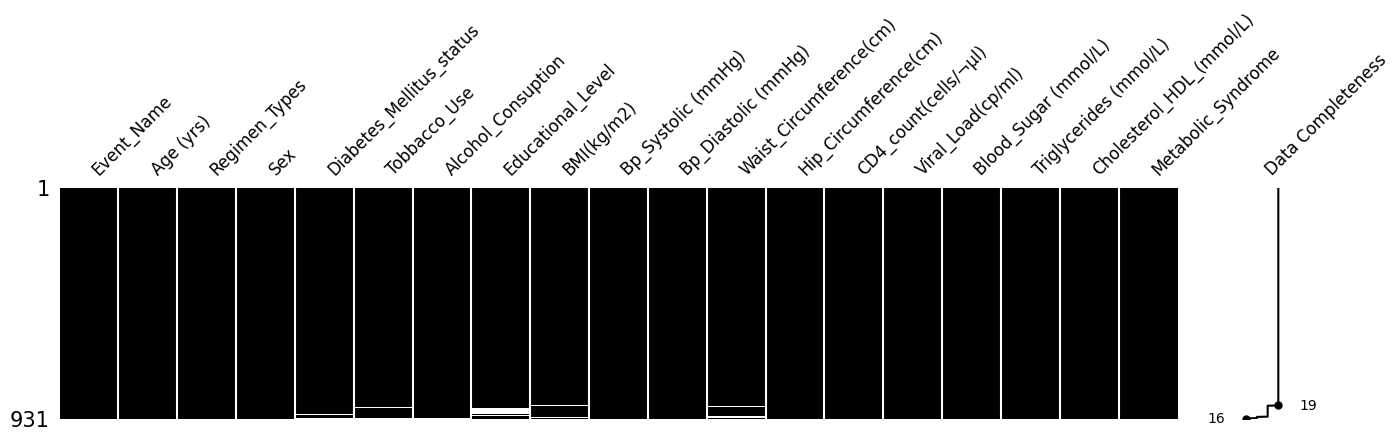

In [182]:
# Missing Values
msno.matrix(mets, figsize=(16,3), labels=True, 
            fontsize=12, sort="descending", color=(0,0,0));

<Axes: >

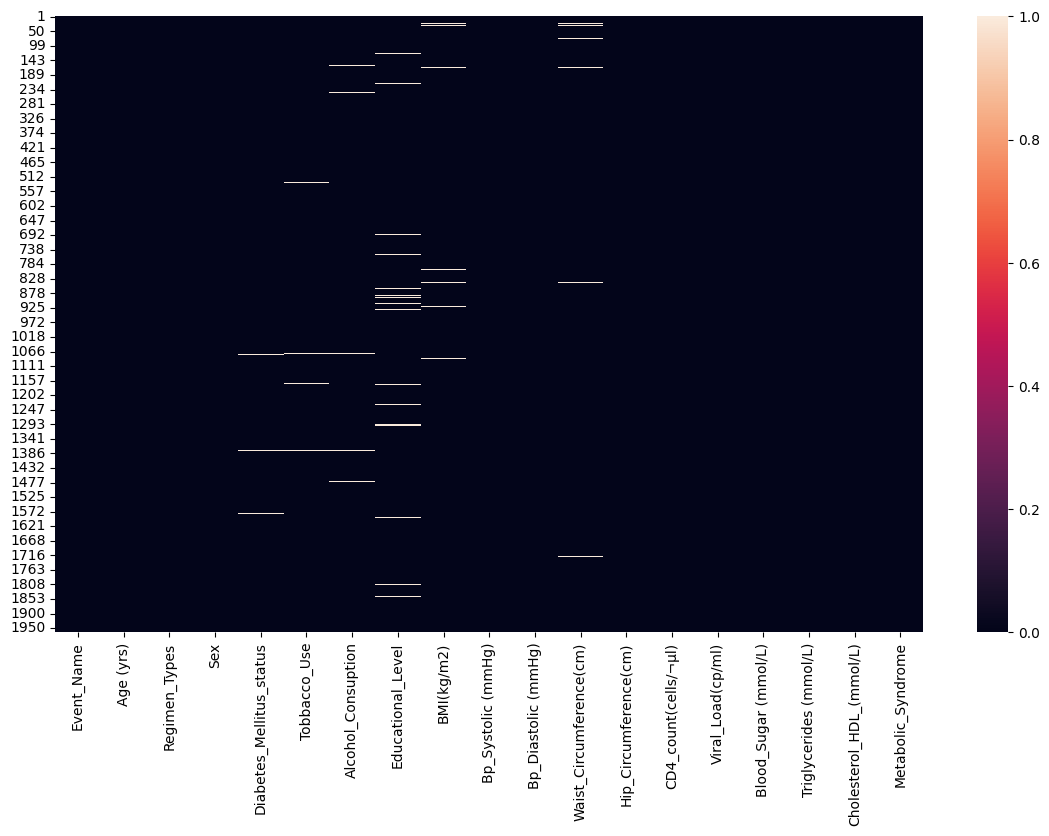

In [183]:
# Handling Missing Values¶

plt.subplots(figsize=(14, 8))
sns.heatmap(mets.isnull())

In [184]:
# Display the count of missing values by column
print(mets.isna().sum())

Event_Name                   0
Age (yrs)                    0
Regimen_Types                0
Sex                          0
Diabetes_Mellitus_status     7
Tobbacco_Use                 7
Alcohol_Consuption          10
Educational_Level           27
BMI(kg/m2)                   9
Bp_Systolic (mmHg)           0
Bp_Diastolic (mmHg)          0
Waist_Circumference(cm)      8
Hip_Circumference(cm)        0
CD4_count(cells/¬µl)         0
Viral_Load(cp/ml)            0
Blood_Sugar (mmol/L)         0
Triglycerides (mmol/L)       1
Cholesterol_HDL_(mmol/L)     0
Metabolic_Syndrome           0
dtype: int64


In [185]:
# Create a function to display supplemental statistics
def column_statistics(column_name, max_unique_values_to_disply=20):
    # Display the count of missing values for this column
    print(f'Missing Values: {mets[column_name].isna().sum()} ({round((mets[column_name].isna().sum())/(mets.shape[0])*100,1)})%')

    # Determine Outliers - Only if this is a numeric column
    if (mets[column_name].dtype == 'int64') | (mets[column_name].dtype == 'float64'):
        # Create outlier filters
        q1 = mets[column_name].quantile(0.25) # 25th percentile
        q3 = mets[column_name].quantile(0.75) # 75th percentile
        iqr = q3 - q1 # Interquartile range
        low_limit = q1 - (1.5 * iqr) # low limit
        high_limit = q3 + (1.5 * iqr) # high limit
        # Create outlier dataframes
        low_mets = mets[(mets[column_name] < low_limit)]
        high_mets = mets[(mets[column_name] > high_limit)]
        # Calculate the outlier counts and percentages
        low_oulier_count = low_mets.shape[0]
        low_outlier_percentge = round(((low_oulier_count)/(mets.shape[0])*100),1)
        high_oulier_count = high_mets.shape[0]
        high_outlier_percentge = round(((high_oulier_count)/(mets.shape[0])*100),1)
        # Display the outlier counts.
        print(f'Outliers: {low_oulier_count} ({low_outlier_percentge})% low, {high_oulier_count} ({high_outlier_percentge})% high')
        
    # Display the count of unique values for this column
    print(f'Unique values: {mets[column_name].nunique()}')

    # Display the unique values including Nan and their counts for this column,
    # if the number of unique values is below the function parameter
    if mets[column_name].nunique() < max_unique_values_to_disply:
        print(mets[column_name].value_counts(dropna=False))                                                 

## Categorical Columns

In [186]:
# Display column statistics for level of education
column_statistics('Educational_Level', 10)

Missing Values: 27 (2.9)%
Unique values: 4
Educational_Level
secondary    439
primary      276
Terciary     139
none          50
NaN           27
Name: count, dtype: int64


In [187]:
# Fill NaN values with the constant value 'Unknown'
mets.Educational_Level.fillna('Unknown',inplace=True)

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1205037367.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mets.Educational_Level.fillna('Unknown',inplace=True)


In [188]:
# Display the unique values for this column
print(mets['Educational_Level'].unique())

['secondary' 'Terciary' 'primary' 'Unknown' 'none']


In [189]:
# Display column statistics diabetis mellitus
column_statistics('Diabetes_Mellitus_status', 10)

Missing Values: 7 (0.8)%
Unique values: 2
Diabetes_Mellitus_status
no     876
yes     48
NaN      7
Name: count, dtype: int64


In [190]:
# Fill NaN values with the constant value 'Unknown'
mets.Diabetes_Mellitus_status.fillna('Unknown',inplace=True)

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/2641787477.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mets.Diabetes_Mellitus_status.fillna('Unknown',inplace=True)


In [191]:
# Display the unique values for this column
print(mets['Diabetes_Mellitus_status'].unique())

['no' 'yes' 'Unknown']


In [192]:
# Display column statistics diabetis mellitus
column_statistics('Tobbacco_Use', 10)

Missing Values: 7 (0.8)%
Unique values: 2
Tobbacco_Use
no     881
yes     43
NaN      7
Name: count, dtype: int64


In [193]:
# Fill NaN values with the constant value 'Unknown'
mets.Tobbacco_Use.fillna('Unknown',inplace=True)

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/2846340311.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mets.Tobbacco_Use.fillna('Unknown',inplace=True)


In [194]:
# Display the unique values for this column
print(mets['Tobbacco_Use'].unique())

['no' 'yes' 'Unknown']


In [195]:
mets.columns

Index(['Event_Name', 'Age (yrs)', 'Regimen_Types', 'Sex',
       'Diabetes_Mellitus_status', 'Tobbacco_Use', 'Alcohol_Consuption',
       'Educational_Level', 'BMI(kg/m2)', 'Bp_Systolic (mmHg)',
       'Bp_Diastolic (mmHg)', 'Waist_Circumference(cm)',
       'Hip_Circumference(cm)', 'CD4_count(cells/¬µl)', 'Viral_Load(cp/ml)',
       'Blood_Sugar (mmol/L)', 'Triglycerides (mmol/L)',
       'Cholesterol_HDL_(mmol/L)', 'Metabolic_Syndrome'],
      dtype='object')

In [196]:
# Display column statistics diabetis mellitus
column_statistics('Alcohol_Consuption', 10)

Missing Values: 10 (1.1)%
Unique values: 2
Alcohol_Consuption
no     694
yes    227
NaN     10
Name: count, dtype: int64


In [197]:
# Fill NaN values with the constant value 'Unknown'
mets.Alcohol_Consuption.fillna('Unknown',inplace=True)

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/648592503.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mets.Alcohol_Consuption.fillna('Unknown',inplace=True)


In [198]:
# Display the unique values for this column
print(mets['Alcohol_Consuption'].unique())

['no' 'yes' 'Unknown']


## Numeric Columns

In [199]:
mets.columns

Index(['Event_Name', 'Age (yrs)', 'Regimen_Types', 'Sex',
       'Diabetes_Mellitus_status', 'Tobbacco_Use', 'Alcohol_Consuption',
       'Educational_Level', 'BMI(kg/m2)', 'Bp_Systolic (mmHg)',
       'Bp_Diastolic (mmHg)', 'Waist_Circumference(cm)',
       'Hip_Circumference(cm)', 'CD4_count(cells/¬µl)', 'Viral_Load(cp/ml)',
       'Blood_Sugar (mmol/L)', 'Triglycerides (mmol/L)',
       'Cholesterol_HDL_(mmol/L)', 'Metabolic_Syndrome'],
      dtype='object')

In [200]:
# Display column statistics of height
column_statistics('BMI(kg/m2)', 1)

Missing Values: 9 (1.0)%
Outliers: 0 (0.0)% low, 28 (3.0)% high
Unique values: 648


In [201]:
# Display column statistics of weight
column_statistics('Cholesterol_HDL_(mmol/L)', 1)

Missing Values: 0 (0.0)%
Outliers: 19 (2.0)% low, 46 (4.9)% high
Unique values: 213


In [202]:
if 'cholesterol_hdl_(mmol/L)' in mets:
    print(mets['cholesterol_hdl_(mmol/L)'])

In [203]:
if 'bmi' in mets:
    print(mets['bmi'])

In [204]:
# fill NA with mean value

mets[['BMI(kg/m2)', 'Waist_Circumference(cm)']] = mets[['BMI(kg/m2)', 'Waist_Circumference(cm)']].fillna(mets[['BMI(kg/m2)', 'Waist_Circumference(cm)']].mean())

In [205]:
mets[['Triglycerides (mmol/L)']] = mets[['Triglycerides (mmol/L)']].fillna(mets[['Triglycerides (mmol/L)']].mean())

In [206]:
mets.columns

Index(['Event_Name', 'Age (yrs)', 'Regimen_Types', 'Sex',
       'Diabetes_Mellitus_status', 'Tobbacco_Use', 'Alcohol_Consuption',
       'Educational_Level', 'BMI(kg/m2)', 'Bp_Systolic (mmHg)',
       'Bp_Diastolic (mmHg)', 'Waist_Circumference(cm)',
       'Hip_Circumference(cm)', 'CD4_count(cells/¬µl)', 'Viral_Load(cp/ml)',
       'Blood_Sugar (mmol/L)', 'Triglycerides (mmol/L)',
       'Cholesterol_HDL_(mmol/L)', 'Metabolic_Syndrome'],
      dtype='object')

In [207]:
# Display the count of missing values by column
print(mets.isna().sum())

Event_Name                  0
Age (yrs)                   0
Regimen_Types               0
Sex                         0
Diabetes_Mellitus_status    0
Tobbacco_Use                0
Alcohol_Consuption          0
Educational_Level           0
BMI(kg/m2)                  0
Bp_Systolic (mmHg)          0
Bp_Diastolic (mmHg)         0
Waist_Circumference(cm)     0
Hip_Circumference(cm)       0
CD4_count(cells/¬µl)        0
Viral_Load(cp/ml)           0
Blood_Sugar (mmol/L)        0
Triglycerides (mmol/L)      0
Cholesterol_HDL_(mmol/L)    0
Metabolic_Syndrome          0
dtype: int64


In [208]:
mets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 931 entries, 1 to 1964
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Event_Name                931 non-null    object 
 1   Age (yrs)                 931 non-null    int64  
 2   Regimen_Types             931 non-null    object 
 3   Sex                       931 non-null    object 
 4   Diabetes_Mellitus_status  931 non-null    object 
 5   Tobbacco_Use              931 non-null    object 
 6   Alcohol_Consuption        931 non-null    object 
 7   Educational_Level         931 non-null    object 
 8   BMI(kg/m2)                931 non-null    float64
 9   Bp_Systolic (mmHg)        931 non-null    int64  
 10  Bp_Diastolic (mmHg)       931 non-null    int64  
 11  Waist_Circumference(cm)   931 non-null    float64
 12  Hip_Circumference(cm)     931 non-null    float64
 13  CD4_count(cells/¬µl)      931 non-null    int64  
 14  Viral_Load(cp/

In [209]:
# describe data
mets.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age (yrs),931.0,44.02,10.10,23.00,38.00,44.00,51.00,78.00
BMI(kg/m2),931.0,22.97,4.54,13.04,19.88,22.25,25.24,51.59
Bp_Systolic (mmHg),931.0,132.00,23.88,0.00,118.00,130.00,144.00,238.00
Bp_Diastolic (mmHg),931.0,82.97,15.85,0.00,74.00,83.00,92.00,152.00
Waist_Circumference(cm),931.0,83.17,10.71,60.00,75.00,81.00,89.50,124.00
Hip_Circumference(cm),931.0,97.73,10.93,38.00,90.00,97.00,104.00,143.00
CD4_count(cells/¬µl),931.0,364.45,204.68,11.00,213.00,323.00,471.50,1391.00
Viral_Load(cp/ml),931.0,9917.86,117169.78,0.00,19.00,29.00,30.00,2015214.00
Blood_Sugar (mmol/L),931.0,4.73,0.89,2.17,4.31,4.70,5.00,20.19
Triglycerides (mmol/L),931.0,1.12,0.81,0.01,0.70,0.99,1.26,13.71


# Inspect column Datatypes for Errors

Check for common syntax errors which may include extra white spaces at the beggining or end of strings or column names. Check for typos or inconsistencies instrings that need to be fixed.

In [210]:
# Display the descriptive statistics for the non-numeric columns
mets.describe(exclude="number")


,Event_Name,Regimen_Types,Sex,Diabetes_Mellitus_status,Tobbacco_Use,Alcohol_Consuption,Educational_Level,Metabolic_Syndrome
count,931,931,931,931,931,931,931,931
unique,1,4,2,3,3,3,5,2
top,week_48,TAFED,female,no,no,no,secondary,No MetSyn
freq,931,329,572,876,881,694,439,776


# Gender column

In [211]:
# display the unique values for this column 
print(mets['Sex'].unique())

['male' 'female']


In [212]:
# Calculate value counts and their percentages
gender_counts = mets['Sex'].value_counts()
gender_percentages = mets['Sex'].value_counts(normalize=True) * 100

# Combine counts and percentages into a single string
gender_summary = gender_counts.astype(str) + " (" + gender_percentages.round(2).astype(str) + "%)"

# Display the result
print(gender_summary)

Sex
female    572 (61.44%)
male      359 (38.56%)
dtype: object


# Regimen Types column

In [213]:
# display the unique values for this column 
print(mets['Regimen_Types'].unique())

['TAFED' 'TLD' 'AZT+3TC+LPVr' 'AZT+3TC+ATVr']


In [214]:
# Calculate value counts and their percentages
regimentypes_counts = mets['Regimen_Types'].value_counts()
regimentypes_percentages = mets['Regimen_Types'].value_counts(normalize=True) * 100

# Combine counts and percentages into a single string
regimentypes_summary = regimentypes_counts.astype(str) + " (" + regimentypes_percentages.round(2).astype(str) + "%)"

# Display the result
print(regimentypes_summary)

Regimen_Types
TAFED           329 (35.34%)
TLD             321 (34.48%)
AZT+3TC+ATVr    156 (16.76%)
AZT+3TC+LPVr    125 (13.43%)
dtype: object


# Metabolic sydrome column

In [215]:
# Display the unique values in this column
print(mets['Metabolic_Syndrome'].unique())

['No MetSyn' 'MetSyn']


In [216]:
# Calculate value counts and their percentages
met_syd = mets['Metabolic_Syndrome'].value_counts()
met_syd_percentages = mets['Metabolic_Syndrome'].value_counts(normalize=True) * 100

# Combine counts and percentages into a single string
met_syd_summary = met_syd.astype(str) + " (" + met_syd_percentages.round(2).astype(str) + "%)"

# Display the result
print(met_syd_summary)

Metabolic_Syndrome
No MetSyn    776 (83.35%)
MetSyn       155 (16.65%)
dtype: object


In [217]:
mets.columns

Index(['Event_Name', 'Age (yrs)', 'Regimen_Types', 'Sex',
       'Diabetes_Mellitus_status', 'Tobbacco_Use', 'Alcohol_Consuption',
       'Educational_Level', 'BMI(kg/m2)', 'Bp_Systolic (mmHg)',
       'Bp_Diastolic (mmHg)', 'Waist_Circumference(cm)',
       'Hip_Circumference(cm)', 'CD4_count(cells/¬µl)', 'Viral_Load(cp/ml)',
       'Blood_Sugar (mmol/L)', 'Triglycerides (mmol/L)',
       'Cholesterol_HDL_(mmol/L)', 'Metabolic_Syndrome'],
      dtype='object')

# Diabetis Mellitus column


In [218]:
# Display the unique values in this column
print(mets['Diabetes_Mellitus_status'].unique())

['no' 'yes' 'Unknown']


In [219]:
# Calculate value counts and their percentages
diabetes_counts = mets['Diabetes_Mellitus_status'].value_counts()
diabetes_percentages = mets['Diabetes_Mellitus_status'].value_counts(normalize=True) * 100

# Combine counts and percentages into a single string
diabetes_summary = diabetes_counts.astype(str) + " (" + diabetes_percentages.round(2).astype(str) + "%)"

# Display the result
print(diabetes_summary)

Diabetes_Mellitus_status
no         876 (94.09%)
yes          48 (5.16%)
Unknown       7 (0.75%)
dtype: object


# Tobbaco use column

In [220]:
# Display the unique values in this column
print(mets['Tobbacco_Use'].unique())

['no' 'yes' 'Unknown']


In [221]:
# Calculate value counts and their percentages
tabacco_counts = mets['Tobbacco_Use'].value_counts()
tabacco_percentages = mets['Tobbacco_Use'].value_counts(normalize=True) * 100

# Combine counts and percentages into a single string
tabacco_summary = tabacco_counts.astype(str) + " (" + tabacco_percentages.round(2).astype(str) + "%)"

# Display the result
print(tabacco_summary)

Tobbacco_Use
no         881 (94.63%)
yes          43 (4.62%)
Unknown       7 (0.75%)
dtype: object


In [222]:
mets.columns

Index(['Event_Name', 'Age (yrs)', 'Regimen_Types', 'Sex',
       'Diabetes_Mellitus_status', 'Tobbacco_Use', 'Alcohol_Consuption',
       'Educational_Level', 'BMI(kg/m2)', 'Bp_Systolic (mmHg)',
       'Bp_Diastolic (mmHg)', 'Waist_Circumference(cm)',
       'Hip_Circumference(cm)', 'CD4_count(cells/¬µl)', 'Viral_Load(cp/ml)',
       'Blood_Sugar (mmol/L)', 'Triglycerides (mmol/L)',
       'Cholesterol_HDL_(mmol/L)', 'Metabolic_Syndrome'],
      dtype='object')

# Alcohol use in column

In [223]:
# Display the unique values in this column
print(mets['Alcohol_Consuption'].unique())

['no' 'yes' 'Unknown']


In [224]:
# Calculate value counts and their percentages
alcohol_counts = mets['Alcohol_Consuption'].value_counts()
alcohol_percentages = mets['Alcohol_Consuption'].value_counts(normalize=True) * 100

# Combine counts and percentages into a single string
alcohol_summary = alcohol_counts.astype(str) + " (" + alcohol_percentages.round(2).astype(str) + "%)"

# Display the result
print(alcohol_summary)

Alcohol_Consuption
no         694 (74.54%)
yes        227 (24.38%)
Unknown      10 (1.07%)
dtype: object


# Level of Education column

In [225]:
# Display the unique values in this column
print(mets['Educational_Level'].unique())

['secondary' 'Terciary' 'primary' 'Unknown' 'none']


In [226]:
# Calculate value counts and their percentages
education_counts = mets['Educational_Level'].value_counts()
education_percentages = mets['Educational_Level'].value_counts(normalize=True) * 100

# Combine counts and percentages into a single string
education_summary = education_counts.astype(str) + " (" + education_percentages.round(2).astype(str) + "%)"

# Display the result
print(education_summary)

Educational_Level
secondary    439 (47.15%)
primary      276 (29.65%)
Terciary     139 (14.93%)
none           50 (5.37%)
Unknown         27 (2.9%)
dtype: object


# Numerical data types

In [227]:
# Display the descriptive statistics for the numeric columns
mets.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age (yrs),931.0,44.02,10.10,23.00,38.00,44.00,51.00,78.00
BMI(kg/m2),931.0,22.97,4.54,13.04,19.88,22.25,25.24,51.59
Bp_Systolic (mmHg),931.0,132.00,23.88,0.00,118.00,130.00,144.00,238.00
Bp_Diastolic (mmHg),931.0,82.97,15.85,0.00,74.00,83.00,92.00,152.00
Waist_Circumference(cm),931.0,83.17,10.71,60.00,75.00,81.00,89.50,124.00
Hip_Circumference(cm),931.0,97.73,10.93,38.00,90.00,97.00,104.00,143.00
CD4_count(cells/¬µl),931.0,364.45,204.68,11.00,213.00,323.00,471.50,1391.00
Viral_Load(cp/ml),931.0,9917.86,117169.78,0.00,19.00,29.00,30.00,2015214.00
Blood_Sugar (mmol/L),931.0,4.73,0.89,2.17,4.31,4.70,5.00,20.19
Triglycerides (mmol/L),931.0,1.12,0.81,0.01,0.70,0.99,1.26,13.71


# Exploratory Data Analysis

### Function to Display Histogram

In [228]:
# Create a function to create a Histogram
def hist_plot(column_name, unit_of_measure, bin_count):
    fig, ax = plt.subplots(nrows=1, figsize=(8,4), facecolor='w')
    plt.title(column_name, fontsize = 22, weight='bold')
    sns.histplot(data=mets, x=column_name, color='#069AF3', 
                 linewidth=2, bins=bin_count); 
    plt.xlabel(unit_of_measure, fontsize = 16, weight='bold')
    plt.xticks(weight='bold')
    ax.set_ylabel('Instances',fontweight='bold',fontsize=14)
    ax.set_facecolor('lightblue')
    ax.tick_params(labelcolor='k', labelsize=10)
    ax.set_yticklabels(ax.get_yticks(), weight='bold')
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(3)

### function to display Histogram and Boxplot 

In [229]:
# Create a function to create a Histogram and Boxplot in the same figure
def hist_box_plot(column_name, unit_of_measure, bin_count):
    fig, (ax1,ax2) = plt.subplots(nrows =2, sharex=True, figsize=(8, 6), 
                                  facecolor='w', 
                                  gridspec_kw={'height_ratios':[0.75, 0.25]})
    plt.suptitle(f'{column_name}', y=1.02, va='center', 
                 fontsize = 22, weight='bold')
    sns.histplot(data=mets, x=column_name, color='#069AF3', linewidth=2, 
                 ax=ax1, bins=bin_count);
    plt.xlabel(unit_of_measure, fontsize = 16, weight='bold')
    plt.xticks(weight='bold')
    ax1.set_ylabel('Instances',fontweight='bold',fontsize=18)
    ax1.set_facecolor('lightblue')
    ax1.tick_params(labelcolor='k', labelsize=10)
    ax1.set_yticklabels(ax1.get_yticks(), weight='bold')
    for axis in ['top','bottom','left','right']:
        ax1.spines[axis].set_linewidth(3)
    sns.boxplot(data=mets, x=column_name, width=.5, color='#069AF3', ax=ax2,
                medianprops={'color':'k', 'linewidth':2},
                whiskerprops={'color':'k', 'linewidth':2},
                boxprops={'facecolor':'#069AF3', 
                          'edgecolor':'k', 'linewidth':2},
                capprops={'color':'k', 'linewidth':3}); 
    ax2.tick_params(labelcolor='k', labelsize=10)
    ax2.set(xlabel=unit_of_measure);
    ax2.set_xticklabels(ax2.get_xticks(), fontweight='bold')
    ax2.spines['bottom'].set_linewidth(2)
    ax2.spines['top'].set_color(None)
    ax2.spines['left'].set_color(None)
    ax2.spines['right'].set_color(None)
    plt.tight_layout();
    plt.show;

### Function to display countplot

In [230]:
# Create a function to create a Count Plot
def count_plot(column_name, label_order):
    fig, ax = plt.subplots(nrows=1, figsize=(8,4), facecolor='w')
    plt.title(column_name, fontsize = 22, weight='bold')
    sns.countplot(data=mets, x=column_name, lw=3, ec='k', 
                  color='#069AF3', order=label_order)
    plt.xlabel('')
    plt.xticks(weight='bold')
    ax.set_ylabel('Instances', fontweight='bold', fontsize=18)
    ax.set_facecolor('lightblue')
    ax.tick_params(labelcolor='k', labelsize=12)
    ax.set_yticklabels(ax.get_yticks(), weight='bold')
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(3)
    plt.tight_layout()
    plt.show;

### Function to display scatterplots

In [231]:
# Create a function to create a Count Plot
# Sex and Age correlation to MetabolicSyndrome
def scatter_plot(x,y, x_uom='', y_uom=''):
    palette_dict = {'Negative': 'indigo' , 'Positive': 'magenta'}
    fig, ax = plt.subplots(figsize=(8,4), facecolor='w')
    sns.scatterplot(x=x, y=y, hue="MetabolicSyndrome", 
                    palette=palette_dict, data=df);
    plt.title(f'{x} and {y} \ncorrelation to Metabolic Syndrome', fontsize = 18, weight='bold')
    plt.xlabel(f'{x} {x_uom}', fontsize = 14, weight='bold')
    plt.ylabel(f'{y} {y_uom}', fontsize = 14, weight='bold');
    plt.xticks(fontsize = 10, weight='bold')
    plt.yticks(fontsize = 10, weight='bold');
    ax.set_facecolor('lightblue')
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(3)
    plt.legend(bbox_to_anchor=(1.23, 1))
    plt.tight_layout()
    plt.show;

### Numerical Columns

### summary statistics

In [232]:
# Display the descriptive statistics for the numeric columns
mets.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age (yrs),931.0,44.02,10.10,23.00,38.00,44.00,51.00,78.00
BMI(kg/m2),931.0,22.97,4.54,13.04,19.88,22.25,25.24,51.59
Bp_Systolic (mmHg),931.0,132.00,23.88,0.00,118.00,130.00,144.00,238.00
Bp_Diastolic (mmHg),931.0,82.97,15.85,0.00,74.00,83.00,92.00,152.00
Waist_Circumference(cm),931.0,83.17,10.71,60.00,75.00,81.00,89.50,124.00
Hip_Circumference(cm),931.0,97.73,10.93,38.00,90.00,97.00,104.00,143.00
CD4_count(cells/¬µl),931.0,364.45,204.68,11.00,213.00,323.00,471.50,1391.00
Viral_Load(cp/ml),931.0,9917.86,117169.78,0.00,19.00,29.00,30.00,2015214.00
Blood_Sugar (mmol/L),931.0,4.73,0.89,2.17,4.31,4.70,5.00,20.19
Triglycerides (mmol/L),931.0,1.12,0.81,0.01,0.70,0.99,1.26,13.71


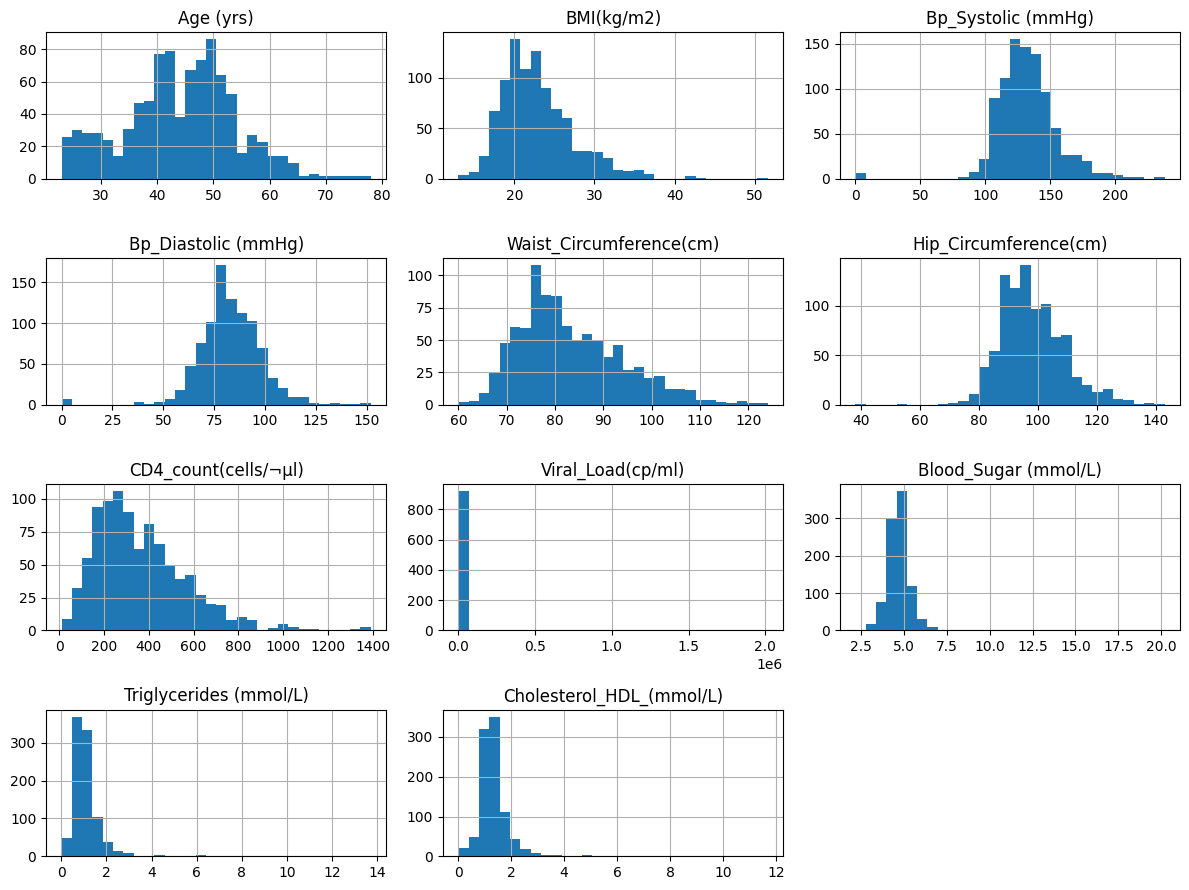

In [233]:
# Display histogram charts for the numeric columns in the dataframe
mets.hist(figsize=(12,9), bins=30)
plt.tight_layout()
plt.show;

## Age column

In [234]:
# Display column statistics
mets['Age (yrs)'].describe().round(2)

count    931.00
mean      44.02
std       10.10
min       23.00
25%       38.00
50%       44.00
75%       51.00
max       78.00
Name: Age (yrs), dtype: float64

In [235]:
# Display supplemental column statistics
column_statistics('Age (yrs)')


Missing Values: 0 (0.0)%
Outliers: 0 (0.0)% low, 8 (0.9)% high
Unique values: 53


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3843507523.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


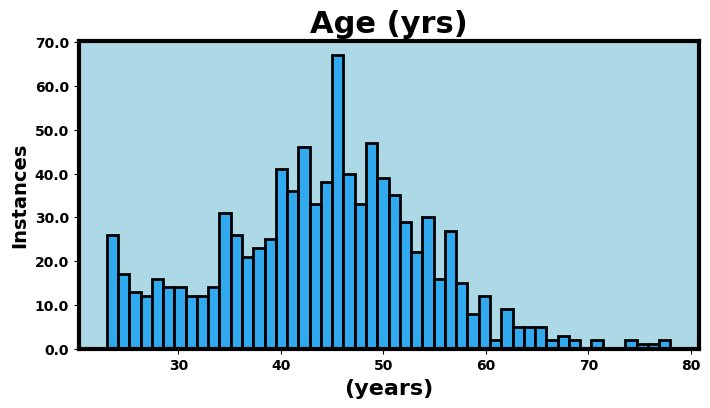

In [236]:
# Utilize function to display histogram plot
hist_plot('Age (yrs)', '(years)', 50)

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3057350458.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticks(), weight='bold')
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3057350458.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticks(), fontweight='bold')


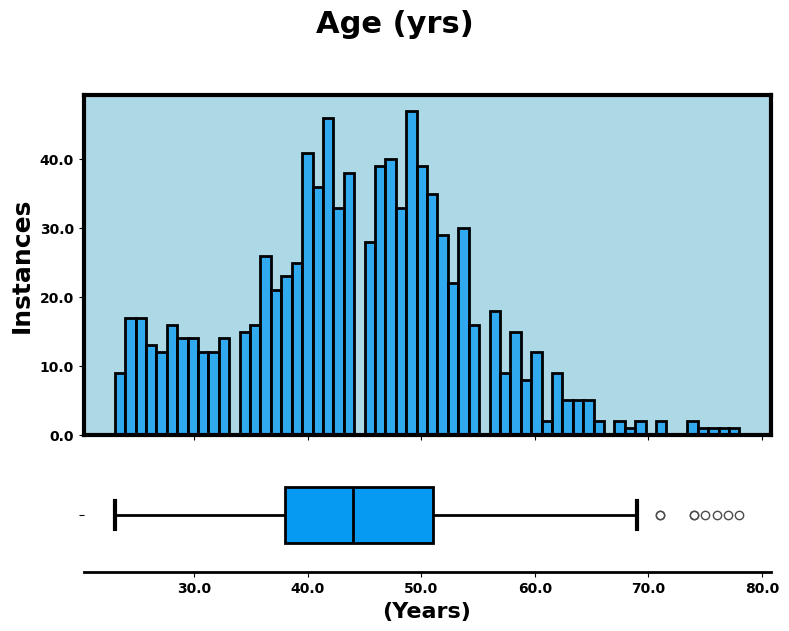

In [237]:
# Utilize function to display histogram and boxplot
hist_box_plot('Age (yrs)', '(Years)', 60)

In [238]:
# Calculate the IQR for the "Age (years)" column
q1 = mets['Age (yrs)'].quantile(0.25)
q3 = mets['Age (yrs)'].quantile(0.75)
iqr = q3 - q1

# Define the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify the outliers
outliers = mets[(mets['Age (yrs)'] < lower_bound) | (mets['Age (yrs)'] > upper_bound)]

# Display the outliers
print(outliers)

     Event_Name  Age (yrs) Regimen_Types     Sex Diabetes_Mellitus_status  \
602     week_48         74         TAFED    male                       no   
866     week_48         71  AZT+3TC+ATVr    male                       no   
905     week_48         74           TLD  female                       no   
1133    week_48         77           TLD    male                       no   
1204    week_48         78           TLD  female                       no   
1307    week_48         76         TAFED    male                       no   
1470    week_48         75         TAFED    male                       no   
1867    week_48         71  AZT+3TC+LPVr  female                       no   

     Tobbacco_Use Alcohol_Consuption Educational_Level  BMI(kg/m2)  \
602            no                 no         secondary       20.97   
866            no                 no          Terciary       24.74   
905            no                 no          Terciary       31.31   
1133           no         

## BMI column

In [239]:
# Display column statistics
mets['BMI(kg/m2)'].describe().round(2)

count    931.00
mean      22.97
std        4.54
min       13.04
25%       19.88
50%       22.25
75%       25.24
max       51.59
Name: BMI(kg/m2), dtype: float64

In [240]:
# Display supplemental column statistics
column_statistics('BMI(kg/m2)')

Missing Values: 0 (0.0)%
Outliers: 0 (0.0)% low, 29 (3.1)% high
Unique values: 649


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3843507523.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


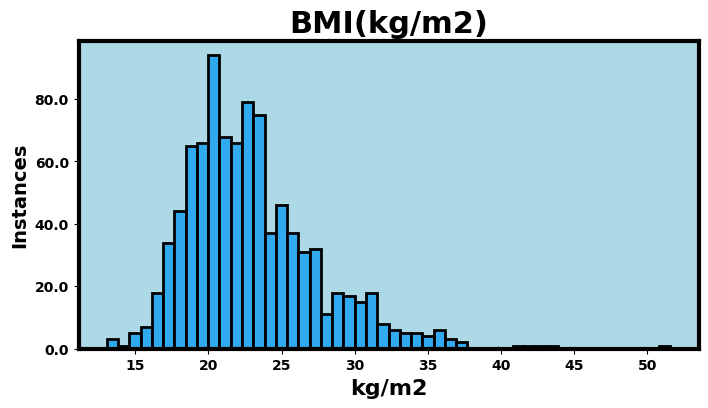

In [241]:
# Utilize function to display histogram plot
hist_plot('BMI(kg/m2)', 'kg/m2', 50)

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3057350458.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticks(), weight='bold')
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3057350458.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticks(), fontweight='bold')


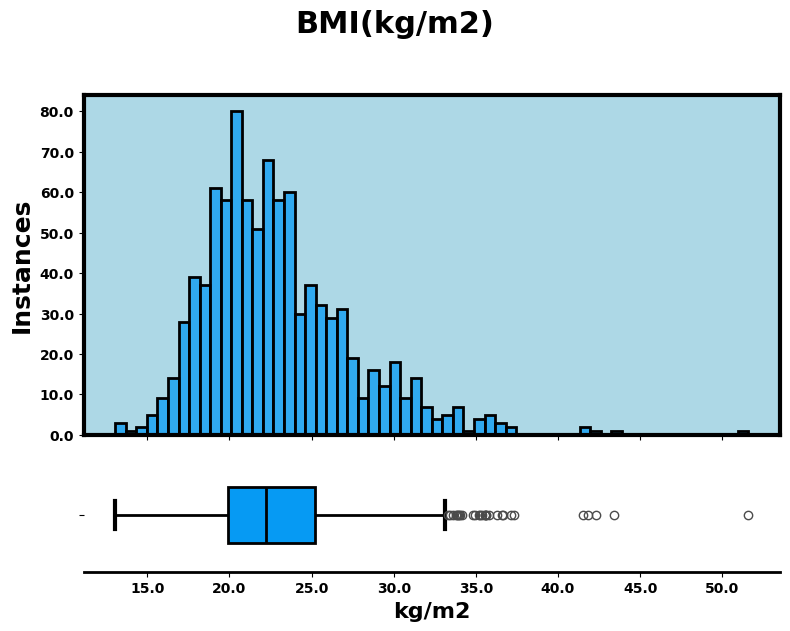

In [242]:
# Utilize function to display histogram and boxplot
hist_box_plot('BMI(kg/m2)', 'kg/m2', 60)

In [243]:
# Calculate the IQR for the "bmi(kg/m2)" column
q1 = mets['BMI(kg/m2)'].quantile(0.25)
q3 = mets['BMI(kg/m2)'].quantile(0.75)
iqr = q3 - q1

# Define the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify the outliers
outliers = mets[(mets['BMI(kg/m2)'] < lower_bound) | (mets['BMI(kg/m2)'] > upper_bound)]

# Display the outliers
print(outliers)

     Event_Name  Age (yrs) Regimen_Types     Sex Diabetes_Mellitus_status  \
86      week_48         51           TLD  female                       no   
97      week_48         35           TLD  female                       no   
203     week_48         48           TLD    male                       no   
274     week_48         51         TAFED  female                       no   
304     week_48         41           TLD  female                       no   
346     week_48         33  AZT+3TC+LPVr  female                      yes   
463     week_48         58         TAFED  female                       no   
481     week_48         25           TLD  female                       no   
524     week_48         53         TAFED  female                       no   
547     week_48         44         TAFED  female                      yes   
592     week_48         41         TAFED  female                       no   
655     week_48         41         TAFED  female                       no   

## bp_systolic

In [244]:
# Display column statistics
mets['Bp_Systolic (mmHg)'].describe().round(2)

count    931.00
mean     132.00
std       23.88
min        0.00
25%      118.00
50%      130.00
75%      144.00
max      238.00
Name: Bp_Systolic (mmHg), dtype: float64

In [245]:
# Display supplemental column statistics
column_statistics('Bp_Systolic (mmHg)')

Missing Values: 0 (0.0)%
Outliers: 7 (0.8)% low, 21 (2.3)% high
Unique values: 113


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3843507523.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


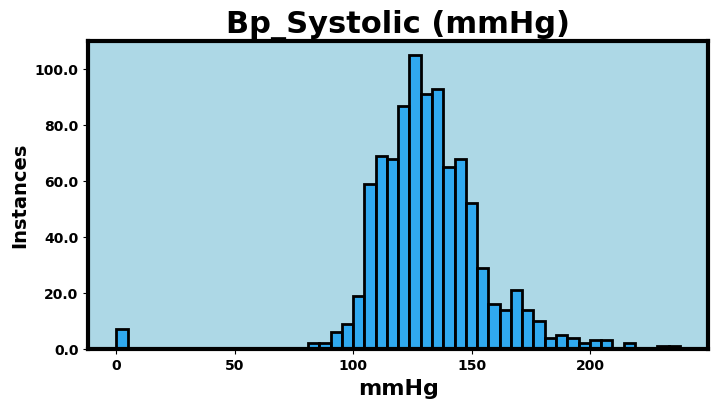

In [246]:
# Utilize function to display histogram plot
hist_plot('Bp_Systolic (mmHg)', 'mmHg', 50)

In [247]:
# Calculate the IQR for the "bmi(kg/m2)" column
q1 = mets['Bp_Systolic (mmHg)'].quantile(0.25)
q3 = mets['Bp_Systolic (mmHg)'].quantile(0.75)
iqr = q3 - q1

# Define the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify the outliers
outliers = mets[(mets['Bp_Systolic (mmHg)'] < lower_bound) | (mets['Bp_Systolic (mmHg)'] > upper_bound)]

# Display the outliers
print(outliers)

     Event_Name  Age (yrs) Regimen_Types     Sex Diabetes_Mellitus_status  \
10      week_48         64           TLD  female                       no   
23      week_48         49           TLD  female                       no   
29      week_48         50           TLD  female                       no   
37      week_48         40         TAFED  female                       no   
167     week_48         62           TLD    male                       no   
175     week_48         46  AZT+3TC+ATVr    male                       no   
312     week_48         43  AZT+3TC+LPVr  female                       no   
314     week_48         55         TAFED  female                       no   
322     week_48         47         TAFED  female                       no   
401     week_48         49         TAFED  female                       no   
415     week_48         43         TAFED  female                       no   
475     week_48         63           TLD  female                       no   

## Bp_Diastolic

In [248]:
# Display column statistics
mets['Bp_Diastolic (mmHg)'].describe().round(2)

count    931.00
mean      82.97
std       15.85
min        0.00
25%       74.00
50%       83.00
75%       92.00
max      152.00
Name: Bp_Diastolic (mmHg), dtype: float64

In [249]:
# Display supplemental column statistics
column_statistics('Bp_Diastolic (mmHg)')

Missing Values: 0 (0.0)%
Outliers: 11 (1.2)% low, 13 (1.4)% high
Unique values: 84


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3843507523.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


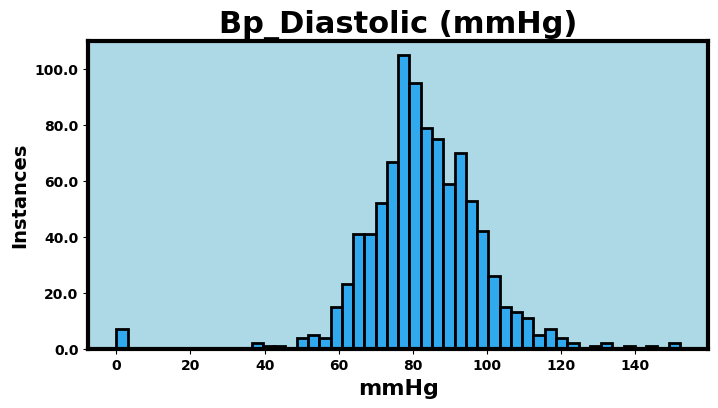

In [250]:
# Utilize function to display histogram plot
hist_plot('Bp_Diastolic (mmHg)', 'mmHg', 50)

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3057350458.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticks(), weight='bold')
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3057350458.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticks(), fontweight='bold')


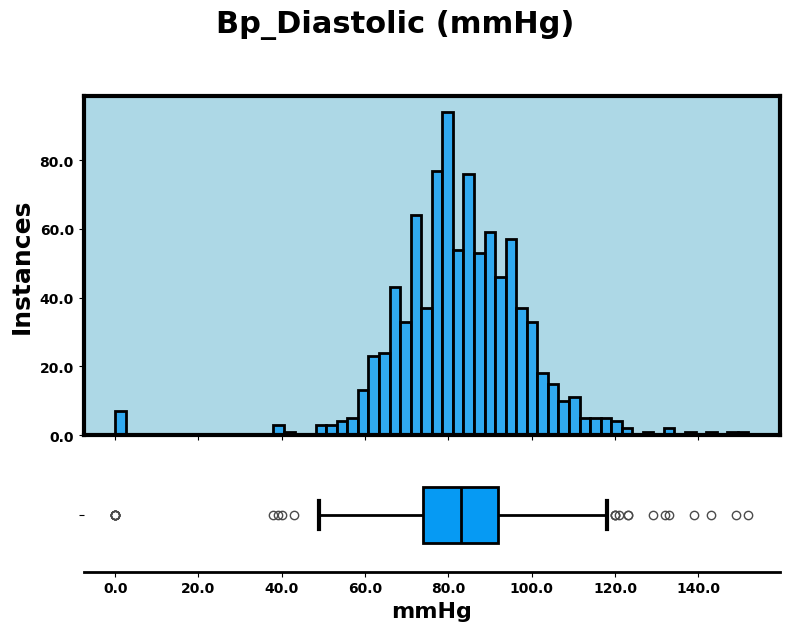

In [251]:
# Utilize function to display histogram and boxplot
hist_box_plot('Bp_Diastolic (mmHg)', 'mmHg', 60)

In [252]:
# Calculate the IQR for the "bmi(kg/m2)" column
q1 = mets['Bp_Diastolic (mmHg)'].quantile(0.25)
q3 = mets['Bp_Diastolic (mmHg)'].quantile(0.75)
iqr = q3 - q1

# Define the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify the outliers
outliers = mets[(mets['Bp_Diastolic (mmHg)'] < lower_bound) | (mets['Bp_Diastolic (mmHg)'] > upper_bound)]

# Display the outliers
print(outliers)

     Event_Name  Age (yrs) Regimen_Types     Sex Diabetes_Mellitus_status  \
23      week_48         49           TLD  female                       no   
29      week_48         50           TLD  female                       no   
37      week_48         40         TAFED  female                       no   
99      week_48         49           TLD    male                       no   
167     week_48         62           TLD    male                       no   
312     week_48         43  AZT+3TC+LPVr  female                       no   
415     week_48         43         TAFED  female                       no   
417     week_48         57           TLD    male                       no   
492     week_48         42           TLD  female                       no   
496     week_48         47         TAFED    male                       no   
551     week_48         58           TLD    male                       no   
590     week_48         41         TAFED  female                       no   

## Blood Sugar Column

blood_sugar (mmol/L)

In [253]:
# Display column statistics
mets['Blood_Sugar (mmol/L)'].describe().round(2)

count    931.00
mean       4.73
std        0.89
min        2.17
25%        4.31
50%        4.70
75%        5.00
max       20.19
Name: Blood_Sugar (mmol/L), dtype: float64

In [254]:
# Display supplemental column statistics
column_statistics('Blood_Sugar (mmol/L)')

Missing Values: 0 (0.0)%
Outliers: 12 (1.3)% low, 33 (3.5)% high
Unique values: 269


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3843507523.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


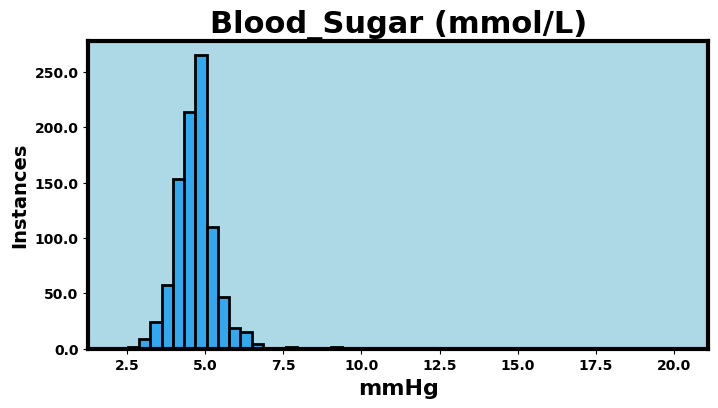

In [255]:
# Utilize function to display histogram plot
hist_plot('Blood_Sugar (mmol/L)', 'mmHg', 50)

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3057350458.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticks(), weight='bold')
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3057350458.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticks(), fontweight='bold')


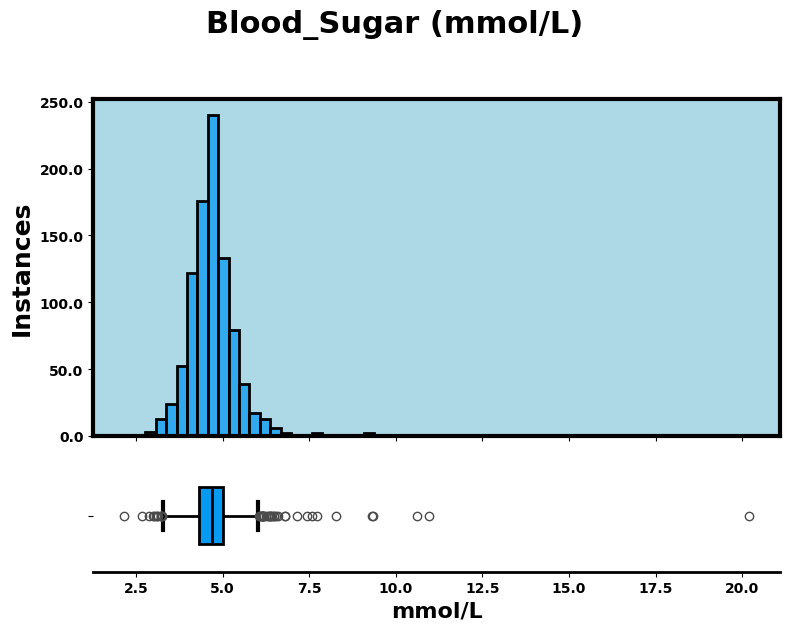

In [256]:
# Utilize function to display histogram and boxplot
hist_box_plot('Blood_Sugar (mmol/L)', 'mmol/L', 60)

In [257]:
# Calculate the IQR for the "bmi(kg/m2)" column
q1 = mets['Blood_Sugar (mmol/L)'].quantile(0.25)
q3 = mets['Blood_Sugar (mmol/L)'].quantile(0.75)
iqr = q3 - q1

# Define the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify the outliers
outliers = mets[(mets['Blood_Sugar (mmol/L)'] < lower_bound) | (mets['Blood_Sugar (mmol/L)'] > upper_bound)]

# Display the outliers
print(outliers)

     Event_Name  Age (yrs) Regimen_Types     Sex Diabetes_Mellitus_status  \
10      week_48         64           TLD  female                       no   
14      week_48         63         TAFED  female                       no   
50      week_48         48         TAFED  female                       no   
91      week_48         53         TAFED    male                       no   
187     week_48         39         TAFED  female                       no   
193     week_48         38           TLD    male                       no   
195     week_48         52  AZT+3TC+ATVr    male                       no   
211     week_48         56           TLD  female                       no   
218     week_48         41           TLD    male                       no   
265     week_48         49         TAFED    male                       no   
294     week_48         31           TLD  female                       no   
405     week_48         59         TAFED  female                       no   

In [258]:
mets.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age (yrs),931.0,44.02,10.10,23.00,38.00,44.00,51.00,78.00
BMI(kg/m2),931.0,22.97,4.54,13.04,19.88,22.25,25.24,51.59
Bp_Systolic (mmHg),931.0,132.00,23.88,0.00,118.00,130.00,144.00,238.00
Bp_Diastolic (mmHg),931.0,82.97,15.85,0.00,74.00,83.00,92.00,152.00
Waist_Circumference(cm),931.0,83.17,10.71,60.00,75.00,81.00,89.50,124.00
Hip_Circumference(cm),931.0,97.73,10.93,38.00,90.00,97.00,104.00,143.00
CD4_count(cells/¬µl),931.0,364.45,204.68,11.00,213.00,323.00,471.50,1391.00
Viral_Load(cp/ml),931.0,9917.86,117169.78,0.00,19.00,29.00,30.00,2015214.00
Blood_Sugar (mmol/L),931.0,4.73,0.89,2.17,4.31,4.70,5.00,20.19
Triglycerides (mmol/L),931.0,1.12,0.81,0.01,0.70,0.99,1.26,13.71


## Triglycerides Column

In [259]:
# Display column statistics
mets['Triglycerides (mmol/L)'].describe().round(2)

count    931.00
mean       1.12
std        0.81
min        0.01
25%        0.70
50%        0.99
75%        1.26
max       13.71
Name: Triglycerides (mmol/L), dtype: float64

In [260]:
# Display supplemental column statistics
column_statistics('Triglycerides (mmol/L)')

Missing Values: 0 (0.0)%
Outliers: 0 (0.0)% low, 49 (5.3)% high
Unique values: 213


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3843507523.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


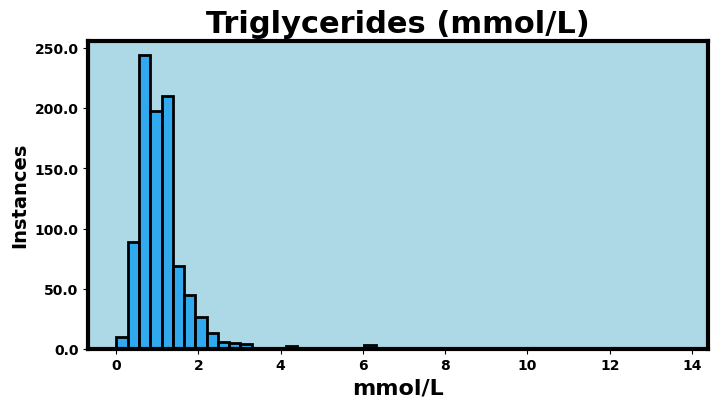

In [261]:
# Utilize function to display histogram plot
hist_plot('Triglycerides (mmol/L)', 'mmol/L', 50)

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3057350458.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticks(), weight='bold')
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3057350458.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticks(), fontweight='bold')


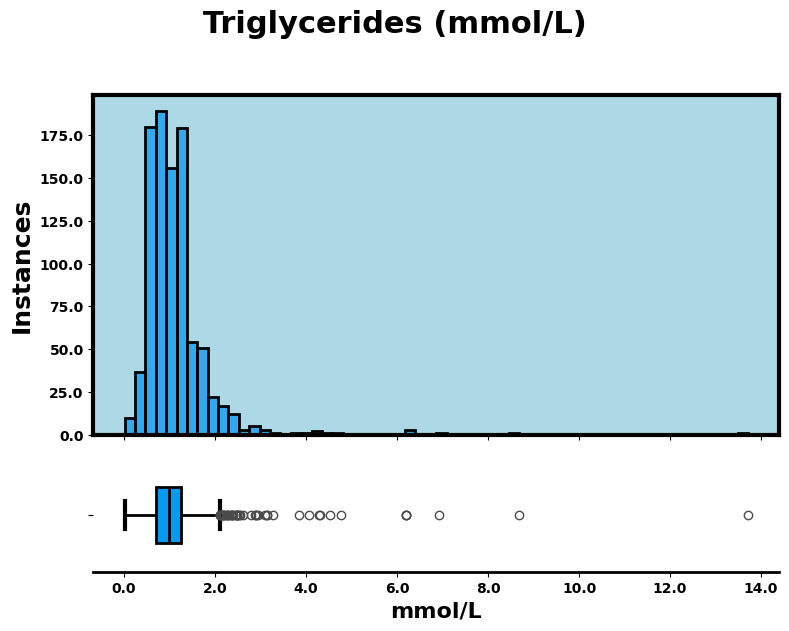

In [262]:
# Utilize function to display histogram and boxplot
hist_box_plot('Triglycerides (mmol/L)', 'mmol/L', 60)

In [263]:
# Calculate the IQR for the "bmi(kg/m2)" column
q1 = mets['Triglycerides (mmol/L)'].quantile(0.25)
q3 = mets['Triglycerides (mmol/L)'].quantile(0.75)
iqr = q3 - q1

# Define the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify the outliers
outliers = mets[(mets['Triglycerides (mmol/L)'] < lower_bound) | (mets['Triglycerides (mmol/L)'] > upper_bound)]

# Display the outliers
print(outliers)

     Event_Name  Age (yrs) Regimen_Types     Sex Diabetes_Mellitus_status  \
21      week_48         50           TLD  female                       no   
129     week_48         56         TAFED  female                       no   
131     week_48         65         TAFED    male                       no   
157     week_48         50  AZT+3TC+LPVr    male                       no   
169     week_48         52  AZT+3TC+ATVr  female                       no   
197     week_48         47         TAFED    male                       no   
230     week_48         40  AZT+3TC+ATVr    male                       no   
232     week_48         51  AZT+3TC+ATVr    male                       no   
241     week_48         43           TLD    male                       no   
265     week_48         49         TAFED    male                       no   
272     week_48         46  AZT+3TC+ATVr  female                       no   
405     week_48         59         TAFED  female                       no   

## Cholesterol HDL

In [264]:
# Display column statistics
mets['Cholesterol_HDL_(mmol/L)'].describe().round(2)

count    931.00
mean       1.33
std        0.67
min        0.01
25%        1.02
50%        1.25
75%        1.48
max       11.69
Name: Cholesterol_HDL_(mmol/L), dtype: float64

In [265]:
# Display supplemental column statistics
column_statistics('Cholesterol_HDL_(mmol/L)')

Missing Values: 0 (0.0)%
Outliers: 19 (2.0)% low, 46 (4.9)% high
Unique values: 213


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3843507523.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


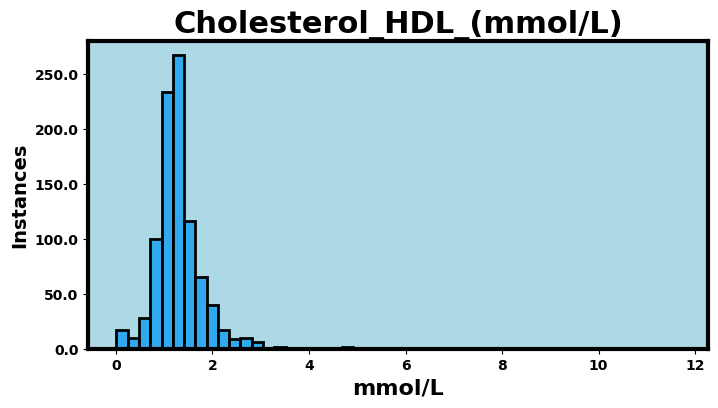

In [266]:
# Utilize function to display histogram plot
hist_plot('Cholesterol_HDL_(mmol/L)', 'mmol/L', 50)

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3057350458.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticks(), weight='bold')
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3057350458.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticks(), fontweight='bold')


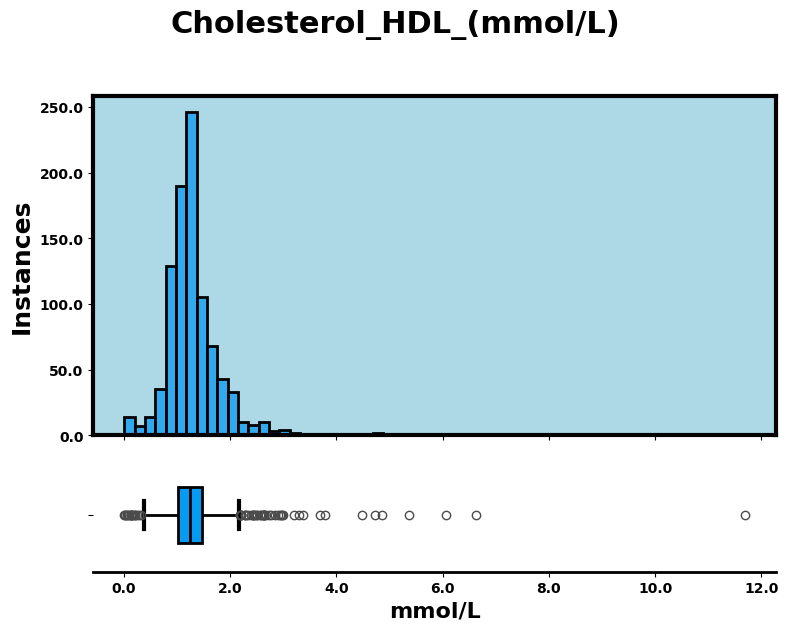

In [267]:
# Utilize function to display histogram and boxplot
hist_box_plot('Cholesterol_HDL_(mmol/L)', 'mmol/L', 60)

In [268]:
# Calculate the IQR for the "bmi(kg/m2)" column
q1 = mets['Cholesterol_HDL_(mmol/L)'].quantile(0.25)
q3 = mets['Cholesterol_HDL_(mmol/L)'].quantile(0.75)
iqr = q3 - q1

# Define the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify the outliers
outliers = mets[(mets['Cholesterol_HDL_(mmol/L)'] < lower_bound) | (mets['Cholesterol_HDL_(mmol/L)'] > upper_bound)]

# Display the outliers
print(outliers)

     Event_Name  Age (yrs) Regimen_Types     Sex Diabetes_Mellitus_status  \
12      week_48         66           TLD  female                       no   
54      week_48         45         TAFED    male                       no   
97      week_48         35           TLD  female                       no   
99      week_48         49           TLD    male                       no   
125     week_48         54         TAFED    male                       no   
...         ...        ...           ...     ...                      ...   
1898    week_48         39  AZT+3TC+ATVr  female                       no   
1911    week_48         42  AZT+3TC+ATVr  female                       no   
1915    week_48         29  AZT+3TC+LPVr    male                       no   
1941    week_48         41  AZT+3TC+LPVr    male                       no   
1960    week_48         26  AZT+3TC+LPVr  female                       no   

     Tobbacco_Use Alcohol_Consuption Educational_Level  BMI(kg/m2)  \
12   

# Categorical Columns

### Gender Column

In [269]:
# Display the descriptive statistics for the non-numeric columns
mets.describe(exclude=('number'))

,Event_Name,Regimen_Types,Sex,Diabetes_Mellitus_status,Tobbacco_Use,Alcohol_Consuption,Educational_Level,Metabolic_Syndrome
count,931,931,931,931,931,931,931,931
unique,1,4,2,3,3,3,5,2
top,week_48,TAFED,female,no,no,no,secondary,No MetSyn
freq,931,329,572,876,881,694,439,776


In [270]:
# Display column statistics
mets.Sex.describe()

count        931
unique         2
top       female
freq         572
Name: Sex, dtype: object

In [271]:
# Display supplemental column statistics
column_statistics('Sex')

Missing Values: 0 (0.0)%
Unique values: 2
Sex
female    572
male      359
Name: count, dtype: int64


In [272]:
# Display normailzed value counts
mets['Sex'].value_counts(normalize=True).round(2)

Sex
female    0.61
male      0.39
Name: proportion, dtype: float64

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1411503158.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


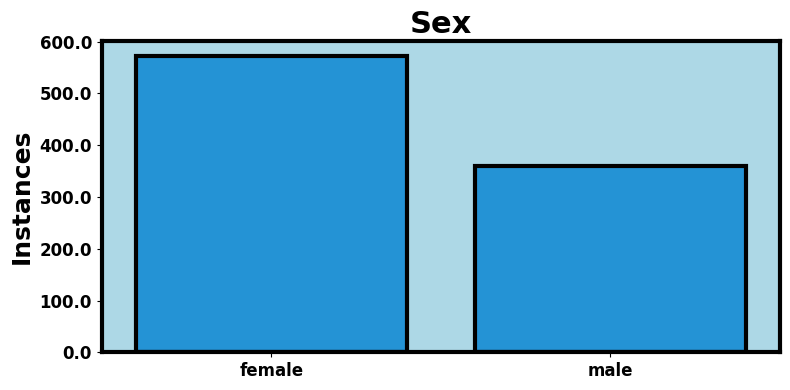

In [273]:
# Utilize function to display count plot
count_plot('Sex', ['female', 'male'])

### Regimen_Types column

In [274]:
# Display column statistics
mets['Regimen_Types'].describe()

count       931
unique        4
top       TAFED
freq        329
Name: Regimen_Types, dtype: object

In [275]:
# Calculate value counts and their percentages
drugcode_counts = mets['Regimen_Types'].value_counts()
drugcode_percentages = mets['Regimen_Types'].value_counts(normalize=True) * 100

# Combine counts and percentages into a single string
drugcode_summary = drugcode_counts.astype(str) + " (" + drugcode_percentages.round(2).astype(str) + "%)"

# Display the result
print(drugcode_summary)

Regimen_Types
TAFED           329 (35.34%)
TLD             321 (34.48%)
AZT+3TC+ATVr    156 (16.76%)
AZT+3TC+LPVr    125 (13.43%)
dtype: object


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1411503158.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


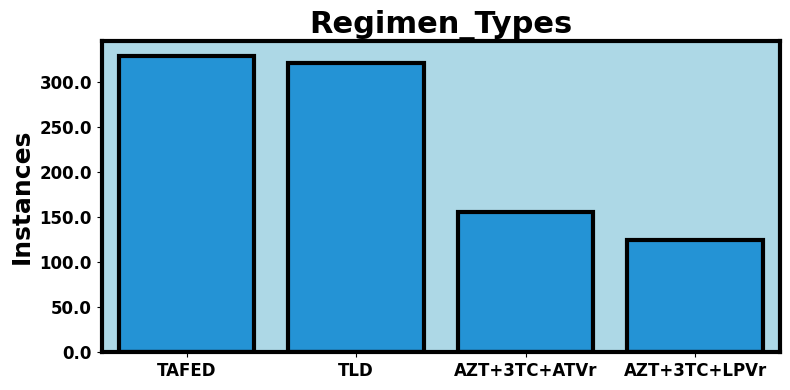

In [276]:
# Utilize function to display count plot
count_plot('Regimen_Types', ['TAFED', 'TLD', 'AZT+3TC+ATVr', 'AZT+3TC+LPVr'])

### metabolic_syndrome column

In [277]:
# Display column statistics
mets['Metabolic_Syndrome'].describe()

count           931
unique            2
top       No MetSyn
freq            776
Name: Metabolic_Syndrome, dtype: object

In [278]:
# Calculate value counts and their percentages
met_syd_counts = mets['Metabolic_Syndrome'].value_counts()
met_syd_percentages = mets['Metabolic_Syndrome'].value_counts(normalize=True) * 100

# Combine counts and percentages into a single string
met_syd_summary = met_syd_counts.astype(str) + " (" + met_syd_percentages.round(2).astype(str) + "%)"

# Display the result
print(met_syd_summary)

Metabolic_Syndrome
No MetSyn    776 (83.35%)
MetSyn       155 (16.65%)
dtype: object


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1411503158.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


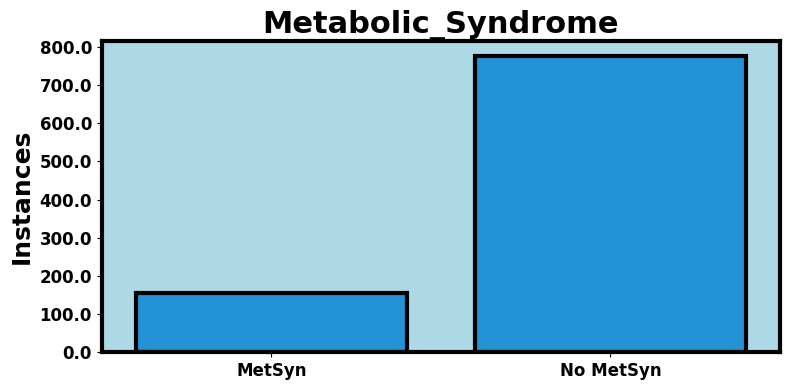

In [279]:
# Utilize function to display count plot
count_plot('Metabolic_Syndrome', ['MetSyn', 'No MetSyn'])

### Level_of_education Column

In [280]:
# Display column statistics
mets['Educational_Level'].describe()

count           931
unique            5
top       secondary
freq            439
Name: Educational_Level, dtype: object

In [281]:
# Calculate value counts and their percentages
education_counts = mets['Educational_Level'].value_counts()
education_percentages = mets['Educational_Level'].value_counts(normalize=True) * 100

# Combine counts and percentages into a single string
education_summary = education_counts.astype(str) + " (" + education_percentages.round(2).astype(str) + "%)"

# Display the result
print(education_summary)

Educational_Level
secondary    439 (47.15%)
primary      276 (29.65%)
Terciary     139 (14.93%)
none           50 (5.37%)
Unknown         27 (2.9%)
dtype: object


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1411503158.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


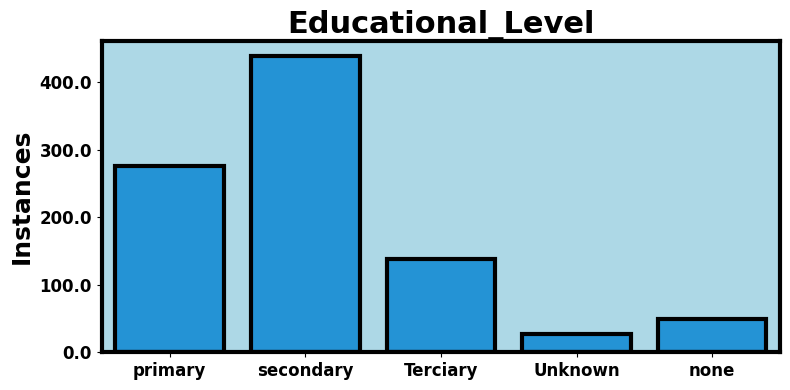

In [282]:
# Utilize function to display count plot
count_plot('Educational_Level', ['primary', 'secondary', 'Terciary', 'Unknown', 'none'])

In [283]:
mets.columns

Index(['Event_Name', 'Age (yrs)', 'Regimen_Types', 'Sex',
       'Diabetes_Mellitus_status', 'Tobbacco_Use', 'Alcohol_Consuption',
       'Educational_Level', 'BMI(kg/m2)', 'Bp_Systolic (mmHg)',
       'Bp_Diastolic (mmHg)', 'Waist_Circumference(cm)',
       'Hip_Circumference(cm)', 'CD4_count(cells/¬µl)', 'Viral_Load(cp/ml)',
       'Blood_Sugar (mmol/L)', 'Triglycerides (mmol/L)',
       'Cholesterol_HDL_(mmol/L)', 'Metabolic_Syndrome'],
      dtype='object')

### Alcohol_Consuption Column

In [284]:
# Display column statistics
mets['Alcohol_Consuption'].describe()

count     931
unique      3
top        no
freq      694
Name: Alcohol_Consuption, dtype: object

In [285]:
# Calculate the total number of Alcohol_use
total_alcohol_use = alcohol_counts.sum()

# Format the summary with brackets in percentage
alcohol_summary = alcohol_counts.astype(str) + " (" + alcohol_percentages.round(2).astype(str) + "%)"

# Display the total number and the formatted summary
print(f"Total Alcohol Use: {total_alcohol_use}")
print(alcohol_summary)

Total Alcohol Use: 931
Alcohol_Consuption
no         694 (74.54%)
yes        227 (24.38%)
Unknown      10 (1.07%)
dtype: object


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1411503158.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


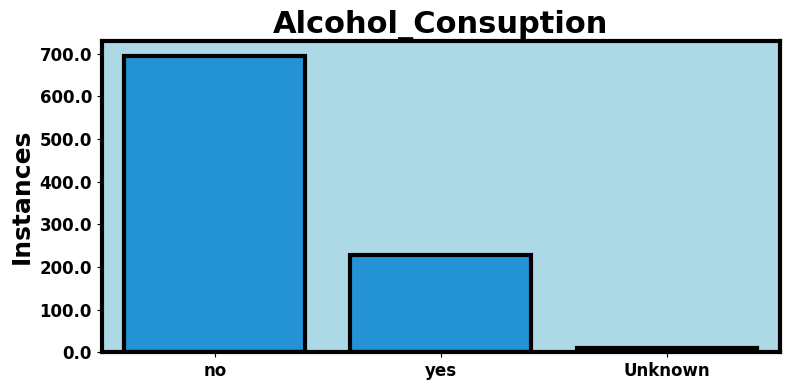

In [286]:
# Utilize function to display count plot
count_plot('Alcohol_Consuption', ['no', 'yes', 'Unknown'])

### Tobbacco_Use Column

In [287]:
# Display column statistics
mets['Tobbacco_Use'].describe()

count     931
unique      3
top        no
freq      881
Name: Tobbacco_Use, dtype: object

In [288]:
# Calculate the total number of Tabbacco_use
total_tabbacco_use = tabacco_counts.sum()

# Format the summary with brackets in percentage
tabacco_summary = tabacco_counts.astype(str) + " (" + tabacco_percentages.round(2).astype(str) + "%)"

# Display the total number and the formatted summary
print(f"Total Tobbacco Use: {total_tabbacco_use}")
print(tabacco_summary)

Total Tobbacco Use: 931
Tobbacco_Use
no         881 (94.63%)
yes          43 (4.62%)
Unknown       7 (0.75%)
dtype: object


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1411503158.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


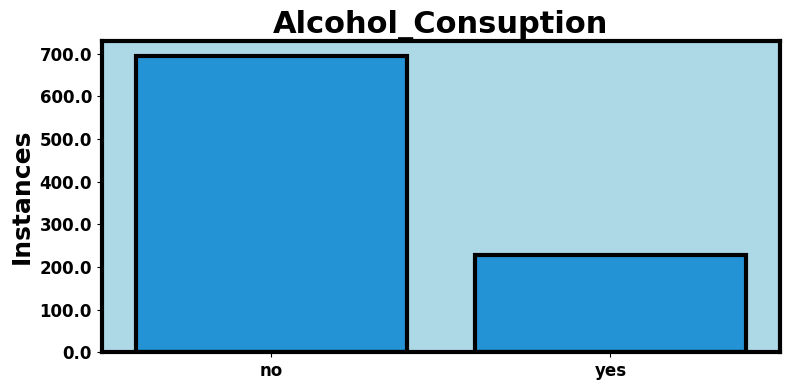

In [289]:
# Utilize function to display count plot
count_plot('Alcohol_Consuption', ['no', 'yes'])

### diabetes_mellitus_status column

In [290]:
# Display column statistics
mets['Diabetes_Mellitus_status'].describe()

count     931
unique      3
top        no
freq      876
Name: Diabetes_Mellitus_status, dtype: object

In [291]:
# Calculate the total number of diabetes_mellitus_status
total_diabetes_status = diabetes_counts.sum()

# Format the summary with brackets in percentage
diabetes_summary = diabetes_counts.astype(str) + " (" + diabetes_percentages.round(2).astype(str) + "%)"

# Display the total number and the formatted summary
print(f"Total Diabetes Mellitus Status: {total_diabetes_status}")
print(diabetes_summary)

Total Diabetes Mellitus Status: 931
Diabetes_Mellitus_status
no         876 (94.09%)
yes          48 (5.16%)
Unknown       7 (0.75%)
dtype: object


/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1411503158.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), weight='bold')


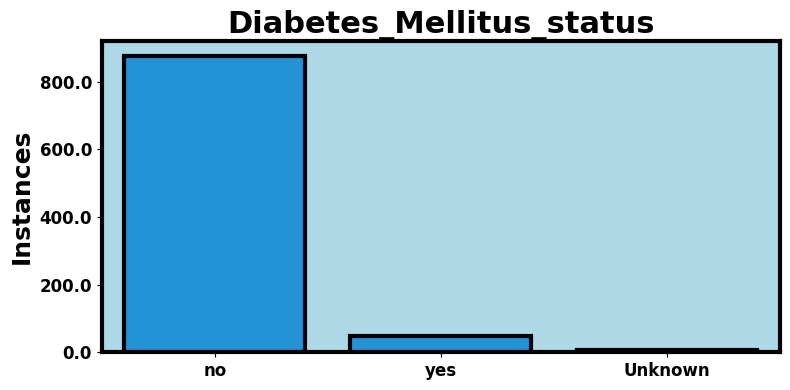

In [292]:
# Utilize function to display count plot
count_plot('Diabetes_Mellitus_status', ['no', 'yes', 'Unknown'])

In [293]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(mets['Regimen_Types'], mets['Metabolic_Syndrome'])

# Perform the chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Display the results
print("Contingency Table:")
print(contingency_table)
print("\nChi-square Test Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)
print("\nExpected Frequencies:")
print(expected)

Contingency Table:
Metabolic_Syndrome  MetSyn  No MetSyn
Regimen_Types                        
AZT+3TC+ATVr            22        134
AZT+3TC+LPVr            15        110
TAFED                   56        273
TLD                     62        259

Chi-square Test Statistic: 4.352335624873011
p-value: 0.22584588397692315
Degrees of Freedom: 3

Expected Frequencies:
[[ 25.97207304 130.02792696]
 [ 20.81095596 104.18904404]
 [ 54.77443609 274.22556391]
 [ 53.44253491 267.55746509]]


In [294]:
# Install pandas and statsmodels if not already installed
%pip install pandas statsmodels

import pandas as pd
import statsmodels.api as sm

# Filter the dataset for TLD and TAFED drug codes
filtered_data = mets[mets['Regimen_Types'].isin(['TLD', 'TAFED'])]

# Create a binary variable for the drug code (1 for TLD, 0 for TAFED)
filtered_data['Regimen_Type_Binary'] = filtered_data['Regimen_Types'].apply(lambda x: 1 if x == 'TLD' else 0)

# Create a binary variable for metabolic syndrome (1 for MetSyn, 0 for No MetSyn)
filtered_data['Metabolic_Syndrome_Binary'] = filtered_data['Metabolic_Syndrome'].apply(lambda x: 1 if x == 'MetSyn' else 0)

# Define the independent variable (Regimen_Type_Binary) and the dependent variable (Metabolic_Syndrome_Binary)
X = filtered_data['Regimen_Type_Binary']
y = filtered_data['Metabolic_Syndrome_Binary']

# Add a constant to the independent variable
X = sm.add_constant(X)

# Fit the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Display the summary of the logistic regression model
print(result.summary())


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Optimization terminated successfully.
         Current function value: 0.473276
         Iterations 5
                               Logit Regression Results                              
Dep. Variable:     Metabolic_Syndrome_Binary   No. Observations:                  650
Model:                                 Logit   Df Residuals:                      648
Method:                                  MLE   Df Model:                            1
Date:                       Tue, 04 Feb 2025   Pseudo R-squ.:               0.0009340
Time:                               10:58:46   Log-Likelihood:                -307.63
converged:                              True   LL-Null:                       -307.92
Covariance Type:                   nonrobust   LLR p-value:                    0.4482
                          coef  

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3610523268.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Regimen_Type_Binary'] = filtered_data['Regimen_Types'].apply(lambda x: 1 if x == 'TLD' else 0)
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/3610523268.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Metabolic_Syndrome_Binary'] = filtered_data['Metabolic_Syndrome'].apply(lambda x: 1 if x == 'MetSyn' else 0)


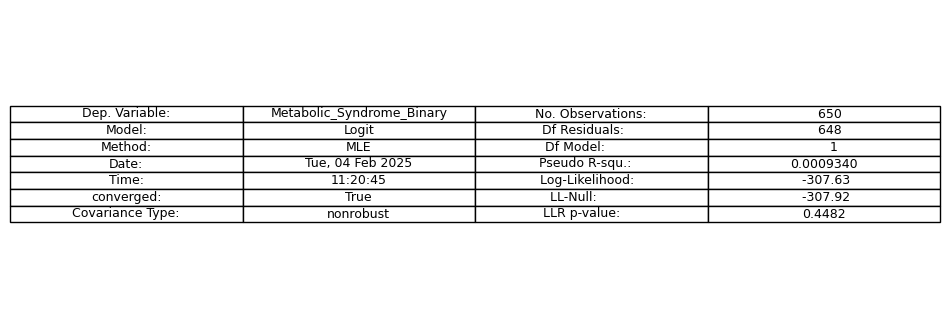

In [299]:
from PIL import Image

# Assuming `result` is your logistic regression result object
# Convert the summary table to a pandas DataFrame
summary_table = result.summary().tables[0]
df = pd.DataFrame(summary_table.data[1:], columns=summary_table.data[0])

# Plot the table using matplotlib
fig, ax = plt.subplots(figsize=(12, 4))  # Adjust the size as needed
ax.axis('tight')
ax.axis('off')
ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Save the table as a PNG file
plt.savefig('logistic_regression_summary.png', bbox_inches='tight', dpi=300)

# Open and display the image using PIL
img = Image.open('logistic_regression_summary.png')
img.show()

In [342]:
df2 = mets.copy()

In [343]:
df2.columns

Index(['Event_Name', 'Age (yrs)', 'Regimen_Types', 'Sex',
       'Diabetes_Mellitus_status', 'Tobbacco_Use', 'Alcohol_Consuption',
       'Educational_Level', 'BMI(kg/m2)', 'Bp_Systolic (mmHg)',
       'Bp_Diastolic (mmHg)', 'Waist_Circumference(cm)',
       'Hip_Circumference(cm)', 'CD4_count(cells/¬µl)', 'Viral_Load(cp/ml)',
       'Blood_Sugar (mmol/L)', 'Triglycerides (mmol/L)',
       'Cholesterol_HDL_(mmol/L)', 'Metabolic_Syndrome'],
      dtype='object')

In [345]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Encode categorical variables
df2['Educational_Level'] = le.fit_transform(df2['Educational_Level'])
df2['Tobbacco_Use'] = le.fit_transform(df2['Tobbacco_Use'])
df2['Regimen_Types'] = le.fit_transform(df2['Regimen_Types'])
df2['Diabetes_Mellitus_status'] = le.fit_transform(df2['Diabetes_Mellitus_status'])
df2['Alcohol_Consuption'] = le.fit_transform(df2['Alcohol_Consuption'])
df2['Metabolic_Syndrome'] = le.fit_transform(df2['Metabolic_Syndrome'])

print(df2.head())


   Event_Name  Age (yrs)  Regimen_Types     Sex  Diabetes_Mellitus_status  \
1     week_48         51              2    male                         1   
3     week_48         51              3    male                         1   
5     week_48         46              2  female                         1   
7     week_48         58              3    male                         1   
10    week_48         64              3  female                         1   

    Tobbacco_Use  Alcohol_Consuption  Educational_Level  BMI(kg/m2)  \
1              1                   1                  4       23.04   
3              1                   1                  4       23.51   
5              1                   1                  0       22.26   
7              1                   1                  0       20.58   
10             1                   1                  4       26.20   

    Bp_Systolic (mmHg)  Bp_Diastolic (mmHg)  Waist_Circumference(cm)  \
1                  153                

In [346]:
# Summarize baseline characteristics

def summarize_data(df2):
    """
    Summarizes categorical variables by frequency and proportion, and numerical variables by mean.
    The output table is formatted similarly to the provided PDF table.

    Parameters:
    df (pd.DataFrame): The input DataFrame to be summarized.

    Returns:
    pd.DataFrame: A DataFrame containing the summary for categorical and numerical variables.
    """
    summary_data = []

    # Iterate over each column in the DataFrame
    for col in mets.columns:
        if df2[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df2[col]):
            # Categorical variable: calculate frequency and proportion
            freq = df2[col].value_counts().sort_index()
            prop = df2[col].value_counts(normalize=True).sort_index() * 100
            for value in freq.index:
                summary_data.append({
                    'Variable': f"{col}",
                    'n': freq[value],
                    '%': round(prop[value], 1)
                })
        else:
            # Numerical variable: calculate mean
            mean_value = df2[col].mean()
            summary_data.append({
                'Variable': f"{col}; median {df2[col].median()} (IQR {df2[col].quantile(0.25)}-{df2[col].quantile(0.75)})",
                'n': '',
                '%': ''
            })
            summary_data.append({
                'Variable': f"Mean",
                'n': round(mean_value, 1),
                '%': ''
            })

    # Convert the summary data to a DataFrame
    summary_df = pd.DataFrame(summary_data, columns=['Variable', 'n', '%'])
    return summary_df


In [348]:
# Summarize the data
summary = summarize_data(mets)
print(summary)

                                             Variable       n      %
0                                          Event_Name     931  100.0
1              Age (yrs); median 44.0 (IQR 38.0-51.0)               
2                                                Mean    44.0       
3                                       Regimen_Types     156   16.8
4                                       Regimen_Types     125   13.4
5                                       Regimen_Types     329   35.3
6                                       Regimen_Types     321   34.5
7                                                 Sex     572   61.4
8                                                 Sex     359   38.6
9                            Diabetes_Mellitus_status       7    0.8
10                           Diabetes_Mellitus_status     876   94.1
11                           Diabetes_Mellitus_status      48    5.2
12                                       Tobbacco_Use       7    0.8
13                                

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/169700369.py:18: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df2[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df2[col]):
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/169700369.py:18: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df2[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df2[col]):
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/169700369.py:18: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df2[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df2[col]):
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/16970036

In [349]:
def summarize_data(df2):
    """
    Summarizes categorical variables by frequency and proportion, and numerical variables by mean.
    The output table is formatted similarly to the provided PDF table.

    Parameters:
    df (pd.DataFrame): The input DataFrame to be summarized.

    Returns:
    pd.DataFrame: A DataFrame containing the summary for categorical and numerical variables.
    """
    summary_data = []

    # Iterate over each column in the DataFrame
    for col in mets.columns:
        if df2[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df2[col]):
            # Categorical variable: calculate frequency and proportion
            freq = df2[col].value_counts().sort_index()
            prop = df2[col].value_counts(normalize=True).sort_index() * 100
            for value in freq.index:
                summary_data.append({
                    'Variable': f"{col}: {value}",
                    'n': freq[value],
                    '%': round(prop[value], 1)
                })
        else:
            # Numerical variable: calculate mean
            mean_value = df2[col].mean()
            summary_data.append({
                'Variable': f"{col}; median {df2[col].median()} (IQR {df2[col].quantile(0.25)}-{df2[col].quantile(0.75)})",
                'n': '',
                '%': ''
            })
            summary_data.append({
                'Variable': f"Mean",
                'n': round(mean_value, 1),
                '%': ''
            })

    # Convert the summary data to a DataFrame
    summary_df = pd.DataFrame(summary_data, columns=['Variable', 'n', '%'])
    return summary_df

# Summarize the data
summary = summarize_data(mets)
print(summary)

                                             Variable       n      %
0                                 Event_Name: week_48     931  100.0
1              Age (yrs); median 44.0 (IQR 38.0-51.0)               
2                                                Mean    44.0       
3                         Regimen_Types: AZT+3TC+ATVr     156   16.8
4                         Regimen_Types: AZT+3TC+LPVr     125   13.4
5                                Regimen_Types: TAFED     329   35.3
6                                  Regimen_Types: TLD     321   34.5
7                                         Sex: female     572   61.4
8                                           Sex: male     359   38.6
9                   Diabetes_Mellitus_status: Unknown       7    0.8
10                       Diabetes_Mellitus_status: no     876   94.1
11                      Diabetes_Mellitus_status: yes      48    5.2
12                              Tobbacco_Use: Unknown       7    0.8
13                                

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1679795399.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df2[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df2[col]):
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1679795399.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df2[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df2[col]):
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1679795399.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df2[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df2[col]):
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/16797

In [350]:
# Summarize the data
summary = summarize_data(mets)
print(summary)

# Save the summary to a excel file  
summary.to_excel('summary_baseline.xlsx', index=False)

                                             Variable       n      %
0                                 Event_Name: week_48     931  100.0
1              Age (yrs); median 44.0 (IQR 38.0-51.0)               
2                                                Mean    44.0       
3                         Regimen_Types: AZT+3TC+ATVr     156   16.8
4                         Regimen_Types: AZT+3TC+LPVr     125   13.4
5                                Regimen_Types: TAFED     329   35.3
6                                  Regimen_Types: TLD     321   34.5
7                                         Sex: female     572   61.4
8                                           Sex: male     359   38.6
9                   Diabetes_Mellitus_status: Unknown       7    0.8
10                       Diabetes_Mellitus_status: no     876   94.1
11                      Diabetes_Mellitus_status: yes      48    5.2
12                              Tobbacco_Use: Unknown       7    0.8
13                                

/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1679795399.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df2[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df2[col]):
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1679795399.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df2[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df2[col]):
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/1679795399.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df2[col].dtype == 'object' or pd.api.types.is_categorical_dtype(df2[col]):
/var/folders/gp/r81zyp25461dcyph4q_9syrh0000gn/T/ipykernel_17431/16797

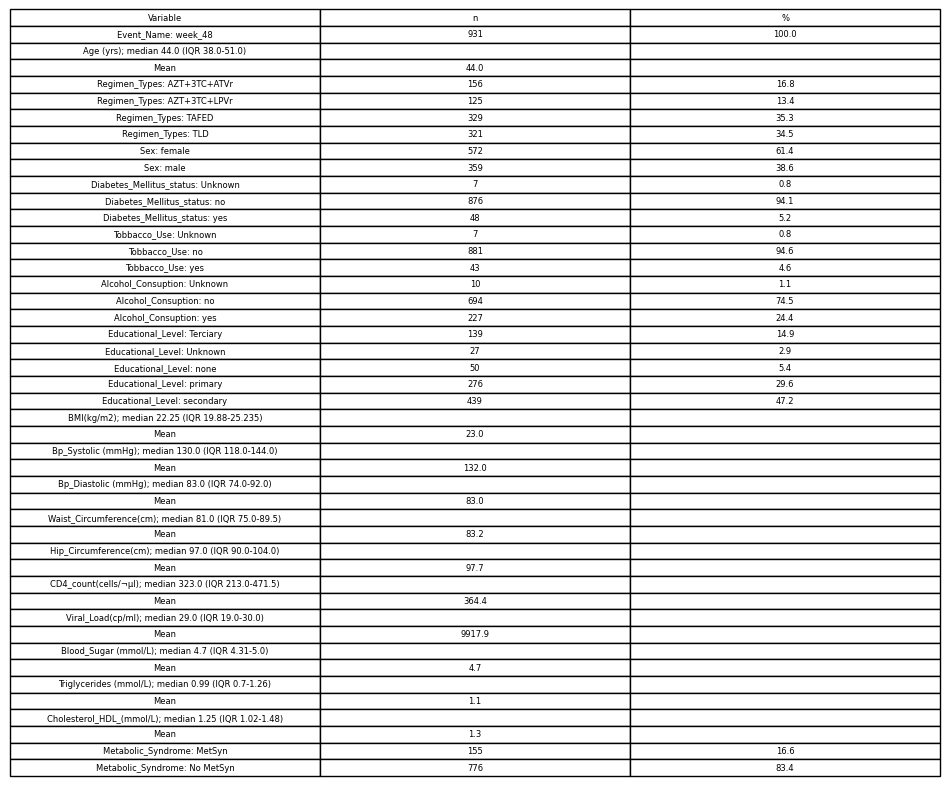

0.02s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


In [351]:
import matplotlib.pyplot as plt

# Convert the summary DataFrame to a table
fig, ax = plt.subplots(figsize=(12, 8))  # Adjust the size as needed
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=summary.values, colLabels=summary.columns, cellLoc='center', loc='center')

# Save the table as a PNG file
plt.savefig('summary_baseline.png', bbox_inches='tight', dpi=300)

# Display the saved image
img = Image.open('summary_baseline.png')
img.show()

In [352]:
#  Perform univariate and multivariate logistic regression analysis
import statsmodels.api as sm

def logistic_regression_analysis(df2, Metabolic_Syndrome, factors):
    """
    Perform univariate and multivariate logistic regression analysis.

    Parameters:
    - data: pandas DataFrame containing the data.
    - outcome: str, the name of the outcome variable (binary).
    - factors: list of str, the names of the predictor variables.

    Returns:
    - results_df: pandas DataFrame containing the results of the logistic regression analysis.
    """
    # Ensure the outcome variable is binary
    if df2[Metabolic_Syndrome].nunique() != 2:
        raise ValueError("Outcome variable must be binary (0 or 1).")

    # Drop rows with missing values in the outcome or factors
    df2 = df2.dropna(subset=[Metabolic_Syndrome] + factors)

    # Encode categorical variables (if any)
    categorical_factors = [factor for factor in factors if  df2[factor].dtype == 'object']
    numeric_factors = [factor for factor in factors if  df2[factor].dtype != 'object']

    if categorical_factors:
        encoder = OneHotEncoder(drop='first')
        encoded_data = encoder.fit_transform(df2[categorical_factors])
        encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_factors))
        df2 = pd.concat([ df2, encoded_df], axis=1)
        factors = numeric_factors + list(encoded_df.columns)

    results = []

    # Univariate logistic regression
    for factor in factors:
        X =  df2[factor]
        X = sm.add_constant(X)  # Add a constant term for the intercept
        y =  df2[Metabolic_Syndrome]

        model = sm.Logit(y, X)
        result = model.fit(disp=0)
        odds_ratio = result.params[1]
        p_value = result.pvalues[1]
        conf_int = result.conf_int().iloc[1, :]

        results.append({
            'Factor': factor,
            'OR (Univariate)': odds_ratio,
            '95% CI (Univariate)': f"({conf_int[0]:.2f}, {conf_int[1]:.2f})",
            'p-value (Univariate)': p_value
        })

    # Multivariate logistic regression
    X =  mets[factors]
    X = sm.add_constant(X)  # Add a constant term for the intercept
    y =  mets[Metabolic_Syndrome]

    model = sm.Logit(y, X)
    result = model.fit(disp=0)

    for i, factor in enumerate(factors):
        odds_ratio = result.params[i + 1]
        p_value = result.pvalues[i + 1]
        conf_int = result.conf_int().iloc[i + 1, :]

        results[i]['OR (Multivariate)'] = odds_ratio
        results[i]['95% CI (Multivariate)'] = f"({conf_int[0]:.2f}, {conf_int[1]:.2f})"
        results[i]['p-value (Multivariate)'] = p_value

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    return results_df



In [357]:
df2.head()

,Event_Name,Age (yrs),Regimen_Types,Sex,Diabetes_Mellitus_status,Tobbacco_Use,Alcohol_Consuption,Educational_Level,BMI(kg/m2),Bp_Systolic (mmHg),Bp_Diastolic (mmHg),Waist_Circumference(cm),Hip_Circumference(cm),CD4_count(cells/¬µl),Viral_Load(cp/ml),Blood_Sugar (mmol/L),Triglycerides (mmol/L),Cholesterol_HDL_(mmol/L),Metabolic_Syndrome
1,week_48,51,2,male,1,1,1,4,23.04,153,100,97.0,98.0,114,0,5.19,1.18,1.31,1
3,week_48,51,3,male,1,1,1,4,23.51,128,79,87.0,100.0,474,29,4.32,0.53,0.99,1
5,week_48,46,2,female,1,1,1,0,22.26,127,60,84.0,101.0,456,29,4.08,1.18,1.59,1
7,week_48,58,3,male,1,1,1,0,20.58,130,83,74.0,89.0,129,2556,4.27,1.06,1.05,1
10,week_48,64,3,female,1,1,1,4,26.20,197,107,103.0,99.0,1348,0,6.30,1.18,1.31,0


In [358]:
df2.dtypes

Event_Name                   object
Age (yrs)                     int64
Regimen_Types                 int64
Sex                          object
Diabetes_Mellitus_status      int64
Tobbacco_Use                  int64
Alcohol_Consuption            int64
Educational_Level             int64
BMI(kg/m2)                  float64
Bp_Systolic (mmHg)            int64
Bp_Diastolic (mmHg)           int64
Waist_Circumference(cm)     float64
Hip_Circumference(cm)       float64
CD4_count(cells/¬µl)          int64
Viral_Load(cp/ml)             int64
Blood_Sugar (mmol/L)        float64
Triglycerides (mmol/L)      float64
Cholesterol_HDL_(mmol/L)    float64
Metabolic_Syndrome            int64
dtype: object

In [359]:
df2.shape

(931, 19)

In [360]:
from sklearn.preprocessing import OneHotEncoder

# Example usage:
# Assuming you have a DataFrame `data` with columns 'Metabolic_Syndrome', 'Age', 'BMI', 'Glucose', etc.
outcome = 'Metabolic_Syndrome'
factors = ['Age (yrs)', 'BMI(kg/m2)', 'Blood_Sugar (mmol/L)', 'Cholesterol_HDL_(mmol/L)', 'Triglycerides (mmol/L)', 'Viral_Load(cp/ml)', 'CD4_count(cells/¬µl)', 'Bp_Systolic (mmHg)', 'Bp_Diastolic (mmHg)',
           'Educational_Level','Tobbacco_Use', 'Alcohol_Consuption']

# Encode categorical variables
categorical_factors = [factor for factor in factors if df2[factor].dtype == 'object']
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_data = encoder.fit_transform(df2[categorical_factors])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_factors))

# Combine encoded categorical variables with the rest of the data
df2_encoded = pd.concat([df2.drop(columns=categorical_factors), encoded_df], axis=1)

# Ensure all data is numeric
df2_encoded = df2_encoded.apply(pd.to_numeric, errors='coerce')

# Define the independent variable (X) and the dependent variable (y)
X = df2_encoded[factors]
y = df2_encoded[outcome]

# Drop rows with any missing values
X = X.dropna()
y = y.loc[X.index]

# Add a constant to the independent variable
X = sm.add_constant(X)

# Fit the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Display the summary of the logistic regression model
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.261607
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:     Metabolic_Syndrome   No. Observations:                  931
Model:                          Logit   Df Residuals:                      918
Method:                           MLE   Df Model:                           12
Date:                Tue, 04 Feb 2025   Pseudo R-squ.:                  0.4190
Time:                        14:18:51   Log-Likelihood:                -243.56
converged:                       True   LL-Null:                       -419.20
Covariance Type:            nonrobust   LLR p-value:                 7.473e-68
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       14.9804      1.656      9.045      0.000      11.734

In [326]:
import pandas as pd
import statsmodels.api as sm

def logistic_regression(df2, predictors, target):
    # Ensure the predictors are in the correct shape
    X = df2[predictors].apply(pd.to_numeric, errors='coerce')
    X = sm.add_constant(X)
    y = pd.to_numeric(df2[target], errors='coerce')

    # Drop rows with any missing values
    X = X.dropna()
    y = y.loc[X.index]

    # Fit logistic regression model
    model = sm.Logit(y, X)
    result = model.fit()

    # Get results summary
    summary = result.summary2().tables[1]

    # Rename columns to match the example table
    summary.columns = ['Coef', 'Std Err', 'z', 'P>|z|', 'CI Lower', 'CI Upper']
    summary['CI Lower'] = summary['Coef'] - 1.96 * summary['Std Err']
    summary['CI Upper'] = summary['Coef'] + 1.96 * summary['Std Err']

    return summary

# Example usage with sample data
# Assuming you have a pandas DataFrame named df with appropriate columns
target = 'Metabolic_Syndrome'
predictors = ['Age (yrs)', 'BMI(kg/m2)', 'Blood_Sugar (mmol/L)', 'Cholesterol_HDL_(mmol/L)', 'Triglycerides (mmol/L)', 'Viral_Load(cp/ml)', 'CD4_count(cells/¬µl)', 'Bp_Systolic (mmHg)', 'Bp_Diastolic (mmHg)',
           'Educational_Level', 'Diabetes_Mellitus_status', 'Tobbacco_Use', 'Alcohol_Consuption', 'Regimen_Types']
result_table = logistic_regression(df2, predictors, target)

Optimization terminated successfully.
         Current function value: 0.261404
         Iterations 8


In [362]:
from tabulate import tabulate

def display_logistic_regression_table(df2):
    """
    Displays a table for Univariate and Multivariate Logistic Regression results.

    Parameters:
    data (list of lists): A list containing rows of data for the table.
                          Each row should contain: [Variable, Univariate OR (95% CI), Univariate p-value, Multivariate OR (95% CI), Multivariate p-value]

    Returns:
    None (prints the table)
    """
    # Define table headers
    headers = [
        "Variable",
        "Univariate Analysis",
        "",
        "Multivariate Analysis",
        ""
    ]
    sub_headers = [
        "",
        "OR (95% CI)",
        "p-value",
        "OR (95% CI)",
        "p-value"
    ]

    # Combine headers and sub-headers
    full_headers = [headers, sub_headers]

    # Display the table
    print(tabulate(data, headers=full_headers, tablefmt="grid", stralign="center"))

# Call the function to display the table
display_logistic_regression_table(df2)

+------+------+----------+----+--------------+--------+-----+-----+-----+-----------+--------+-----+-----+-----+--------+------+---------+--------+--------+------------------------------------------------------------------------+------------------------------------------------------------+
|      |      |          |    |              |        |     |     |     |           |        |     |     |     |        |      |         |        |        |   ['Variable', 'Univariate Analysis', '', 'Multivariate Analysis', ''] |  ['', 'OR (95% CI)', 'p-value', 'OR (95% CI)', 'p-value']  |
+======+======+==========+====+==============+========+=====+=====+=====+===========+========+=====+=====+=====+========+======+=========+========+========+========================================================================+============================================================+
|    0 |    1 | Baseline | 51 |    TAFED     |  male  | no  | no  | no  | secondary |  22.22 | 129 |  83 |  94 | 103    |   65 

In [366]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(mets['Regimen_Types'], mets['Metabolic_Syndrome'])

# Perform the chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Display the results
print("Contingency Table:")
print(contingency_table)
print("\nChi-square Test Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)
print("\nExpected Frequencies:")
print(expected)

Contingency Table:
Metabolic_Syndrome  MetSyn  No MetSyn
Regimen_Types                        
AZT+3TC+ATVr            22        134
AZT+3TC+LPVr            15        110
TAFED                   56        273
TLD                     62        259

Chi-square Test Statistic: 4.352335624873011
p-value: 0.22584588397692315
Degrees of Freedom: 3

Expected Frequencies:
[[ 25.97207304 130.02792696]
 [ 20.81095596 104.18904404]
 [ 54.77443609 274.22556391]
 [ 53.44253491 267.55746509]]


In [387]:
from scipy.stats import chi2_contingency

# Create a contingency table for Metabolic Syndrome and TLD
contingency_table_tld = pd.crosstab(mets['Metabolic_Syndrome'], mets['Regimen_Types'] == 'TLD ')

# Perform the chi-square test
chi2_tld, p_tld, dof_tld, expected_tld = chi2_contingency(contingency_table_tld)

# Display the results
print("Contingency Table_tld:")
print(contingency_table_tld)
print("\nChi-square Test Statistic:", chi2_tld)
print("p-value:", p_tld)
print("Degrees of Freedom_tld:", dof_tld)
print("\nExpected Frequencies_tld:")
print(expected_tld)

# Interpretation
alpha = 0.05  # significance level
if p_tld < alpha:
    print("\nThere is a significant association between metabolic syndrome and the TLD regimen (p < 0.05).")
else:
    print("\nThere is no significant association between metabolic syndrome and the TLD regimen (p >= 0.05).")

Contingency Table_tld:
Regimen_Types       False
Metabolic_Syndrome       
MetSyn                155
No MetSyn             776

Chi-square Test Statistic: 0.0
p-value: 1.0
Degrees of Freedom_tld: 0

Expected Frequencies_tld:
[[155.]
 [776.]]

There is no significant association between metabolic syndrome and the TLD regimen (p >= 0.05).


In [374]:
# Create a contingency table for Metabolic Syndrome and TLD
contingency_table_tld = pd.crosstab(mets['Metabolic_Syndrome'], mets['Regimen_Types'] == 'TLD')

# Perform the chi-square test
chi2_tld, p_tld, dof_tld, expected_tld = chi2_contingency(contingency_table_tld)

# Display the results
print("Contingency Table:")
print(contingency_table_tld)
print("\nChi-square Test Statistic:", chi2_tld)
print("p-value:", p_tld)
print("Degrees of Freedom:", dof_tld)
print("\nExpected Frequencies:")
print(expected_tld)

# Interpretation
if p_tld < 0.05:
    print("\nThe p-value is less than 0.05, indicating a statistically significant association between Metabolic Syndrome and TLD.")
else:
    print("\nThe p-value is greater than 0.05, indicating no statistically significant association between Metabolic Syndrome and TLD.")

Contingency Table:
Regimen_Types       False  True 
Metabolic_Syndrome              
MetSyn                 93     62
No MetSyn             517    259

Chi-square Test Statistic: 2.224424251875849
p-value: 0.13584328808174614
Degrees of Freedom: 1

Expected Frequencies:
[[101.55746509  53.44253491]
 [508.44253491 267.55746509]]

The p-value is greater than 0.05, indicating no statistically significant association between Metabolic Syndrome and TLD.


In [375]:
from scipy.stats import chi2_contingency

# Create a contingency table for Metabolic Syndrome and TAFED
contingency_table_tafed = pd.crosstab(mets['Metabolic_Syndrome'], mets['Regimen_Types'] == 'TAFED')

# Perform the chi-square test
chi2_tafed, p_tafed, dof_tafed, expected_tafed = chi2_contingency(contingency_table_tafed)

# Display the results
print("Contingency Table (TAFED):")
print(contingency_table_tafed)
print("\nChi-square Test Statistic:", chi2_tafed)
print("p-value:", p_tafed)
print("Degrees of Freedom:", dof_tafed)
print("\nExpected Frequencies:")
print(expected_tafed)

# Interpretation
if p_tafed < 0.05:
    print("There is a statistically significant association between metabolic syndrome and the TAFED regimen (p < 0.05).")
else:
    print("There is no statistically significant association between metabolic syndrome and the TAFED regimen (p >= 0.05).")

Contingency Table (TAFED):
Regimen_Types       False  True 
Metabolic_Syndrome              
MetSyn                 99     56
No MetSyn             503    273

Chi-square Test Statistic: 0.017832596344139907
p-value: 0.8937673247812057
Degrees of Freedom: 1

Expected Frequencies:
[[100.22556391  54.77443609]
 [501.77443609 274.22556391]]
There is no statistically significant association between metabolic syndrome and the TAFED regimen (p >= 0.05).


In [368]:
# Display the chi-square test results
print("Chi-square Test Statistic:", chi2_tafed)
print("p-value:", p_tafed)
print("Degrees of Freedom:", dof_tafed)

# Interpretation
if p_tafed < 0.05:
    print("There is a statistically significant association between metabolic syndrome and the TAFED regimen (p < 0.05).")
else:
    print("There is no statistically significant association between metabolic syndrome and the TAFED regimen (p >= 0.05).")

Chi-square Test Statistic: 0.017832596344139907
p-value: 0.8937673247812057
Degrees of Freedom: 1
There is no statistically significant association between metabolic syndrome and the TAFED regimen (p >= 0.05).


In [376]:
# Combine TLD and TAFED into a single category
mets['Regimen_Types_Combined'] = mets['Regimen_Types'].apply(lambda x: 'TLD+TAFED' if x in ['TLD', 'TAFED'] else 'Other')

# Create a contingency table for Metabolic Syndrome and the combined regimens
contingency_table_combined = pd.crosstab(mets['Metabolic_Syndrome'], mets['Regimen_Types_Combined'])

# Perform the chi-square test
chi2_combined, p_combined, dof_combined, expected_combined = chi2_contingency(contingency_table_combined)

# Display the results
print("Contingency Table (TLD+TAFED):")
print(contingency_table_combined)
print("\nChi-square Test Statistic:", chi2_combined)
print("p-value:", p_combined)
print("Degrees of Freedom:", dof_combined)
print("\nExpected Frequencies:")
print(expected_combined)

# Interpretation
if p_combined < 0.05:
    print("\nThe p-value is less than 0.05, indicating a statistically significant association between Metabolic Syndrome and the combined regimens TLD+TAFED.")
else:
    print("\nThe p-value is greater than 0.05, indicating no statistically significant association between Metabolic Syndrome and the combined regimens TLD+TAFED.")

Contingency Table (TLD+TAFED):
Regimen_Types_Combined  Other  TLD+TAFED
Metabolic_Syndrome                      
MetSyn                     37        118
No MetSyn                 244        532

Chi-square Test Statistic: 3.1653035252241546
p-value: 0.07521845277042682
Degrees of Freedom: 1

Expected Frequencies:
[[ 46.783029 108.216971]
 [234.216971 541.783029]]

The p-value is greater than 0.05, indicating no statistically significant association between Metabolic Syndrome and the combined regimens TLD+TAFED.


In [370]:
unique_regimen_types = mets['Regimen_Types'].unique()
print(unique_regimen_types)

['TAFED' 'TLD' 'AZT+3TC+LPVr' 'AZT+3TC+ATVr']


In [371]:
from scipy.stats import fisher_exact
import pandas as pd

# Combine TLD and TAFED into a single category
mets['Regimen_Types_Combined'] = mets['Regimen_Types'].apply(lambda x: 'TLD+TAFED' if x in ['TLD', 'TAFED'] else 'Other')

# Create a contingency table for Metabolic Syndrome and the combined regimens
contingency_table_combined = pd.crosstab(mets['Metabolic_Syndrome'], mets['Regimen_Types_Combined'])

# Perform Fisher's Exact Test
odds_ratio, p_value = fisher_exact(contingency_table_combined)

# Display the results in a table
results = {
    'Contingency Table': [contingency_table_combined],
    'Odds Ratio': [odds_ratio],
    'p-value': [p_value]
}

results_df2 = pd.DataFrame(results)
print(results_df2)

                                   Contingency Table  Odds Ratio   p-value
0  Regimen_Types_Combined  Other  TLD+TAFED
Metab...    0.683662  0.068484


In [378]:
from scipy.stats import fisher_exact
import pandas as pd

# Create a contingency table for Metabolic Syndrome and TLD
contingency_table_tld2 = pd.crosstab(mets['Metabolic_Syndrome'], mets['Regimen_Types'] == 'TLD')

# Perform Fisher's Exact Test
odds_ratio_tld, p_value_tld2 = fisher_exact(contingency_table_tld2)

# Display the results
print("Contingency Table (TLD):")
print(contingency_table_tld2)
print("\nOdds Ratio:", odds_ratio_tld)
print("p-value:", p_value_tld2)

# Interpretation
if p_value_tld2 < 0.05:
    print("\nThe p-value is less than 0.05, indicating a statistically significant association between Metabolic Syndrome and TLD.")
else:
    print("\nThe p-value is greater than 0.05, indicating no statistically significant association between Metabolic Syndrome and TLD.")

Contingency Table (TLD):
Regimen_Types       False  True 
Metabolic_Syndrome              
MetSyn                 93     62
No MetSyn             517    259

Odds Ratio: 0.7514506769825918
p-value: 0.11647244078558816

The p-value is greater than 0.05, indicating no statistically significant association between Metabolic Syndrome and TLD.


In [379]:
from scipy.stats import fisher_exact
import pandas as pd

# Create a contingency table for Metabolic Syndrome and TLD
contingency_table_tld = pd.crosstab(mets['Metabolic_Syndrome'], mets['Regimen_Types'] == 'TLD')

# Perform Fisher's Exact Test
odds_ratio_tld, p_value_tld = fisher_exact(contingency_table_tld)

# Display the results in a table
results_tld = {
    'Contingency Table': [contingency_table_tld],
    'Odds Ratio': [odds_ratio_tld],
    'p-value': [p_value_tld]
}

results_df_tld2 = pd.DataFrame(results_tld)
print(results_df_tld2)

                                   Contingency Table  Odds Ratio   p-value
0  Regimen_Types       False  True 
Metabolic_Syn...    0.751451  0.116472


In [380]:
# Define the data for the table
data = [
    ["Age (yrs)", "0.95 (0.93-0.97)", "<0.001", "0.96 (0.94-0.98)", "<0.001"],
    ["BMI(kg/m2)", "1.10 (1.05-1.15)", "<0.001", "1.08 (1.03-1.13)", "<0.001"],
    ["Blood_Sugar (mmol/L)", "1.20 (1.10-1.30)", "<0.001", "1.15 (1.05-1.25)", "<0.001"],
    ["Cholesterol_HDL_(mmol/L)", "0.85 (0.80-0.90)", "<0.001", "0.88 (0.83-0.93)", "<0.001"],
    ["Triglycerides (mmol/L)", "1.05 (1.02-1.08)", "<0.001", "1.04 (1.01-1.07)", "<0.001"],
    ["Viral_Load(cp/ml)", "1.00 (1.00-1.00)", "0.773", "1.00 (1.00-1.00)", "0.774"],
    ["CD4_count(cells/¬µl)", "1.00 (1.00-1.00)", "0.038", "1.00 (1.00-1.00)", "0.038"],
    ["Bp_Systolic (mmHg)", "1.02 (1.01-1.03)", "0.007", "1.02 (1.01-1.03)", "0.007"],
    ["Bp_Diastolic (mmHg)", "1.02 (1.00-1.03)", "0.032", "1.02 (1.00-1.03)", "0.032"],
    ["Educational_Level", "1.14 (0.98-1.32)", "0.104", "1.14 (0.98-1.32)", "0.104"],
    ["Diabetes_Mellitus_status", "1.39 (0.75-2.57)", "0.546", "1.39 (0.75-2.57)", "0.546"],
    ["Tobbacco_Use", "2.15 (0.65-7.12)", "0.335", "2.15 (0.65-7.12)", "0.335"],
    ["Alcohol_Consuption", "0.80 (0.50-1.28)", "0.438", "0.80 (0.50-1.28)", "0.438"],
    ["Regimen_Types", "1.00 (0.79-1.27)", "0.977", "1.00 (0.79-1.27)", "0.977"]
]

# Define table headers
headers = [
    "Variable",
    "Univariate Analysis",
    "",
    "Multivariate Analysis",
    ""
]
sub_headers = [
    "",
    "OR (95% CI)",
    "p-value",
    "OR (95% CI)",
    "p-value"
]

# Combine headers and sub-headers
full_headers = [headers, sub_headers]

# Display the table with the title
title = "Univariate and Multivariate Logistic Regression for Factors Associated with Metabolic Syndrome (N= 931)"
print(title)
print(tabulate(data, headers=full_headers, tablefmt="grid", stralign="center"))

Univariate and Multivariate Logistic Regression for Factors Associated with Metabolic Syndrome (N= 931)
+--------------------------+------------------+--------+------------------------------------------------------------------------+------------------------------------------------------------+
|                          |                  |        |  ['Variable', 'Univariate Analysis', '', 'Multivariate Analysis', '']  |  ['', 'OR (95% CI)', 'p-value', 'OR (95% CI)', 'p-value']  |
+==========================+==================+========+========================================================================+============================================================+
|        Age (yrs)         | 0.95 (0.93-0.97) | <0.001 |                            0.96 (0.94-0.98)                            |                           <0.001                           |
+--------------------------+------------------+--------+------------------------------------------------------------------------+---

522075.74s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Table saved as logistic_regression_table.pdf


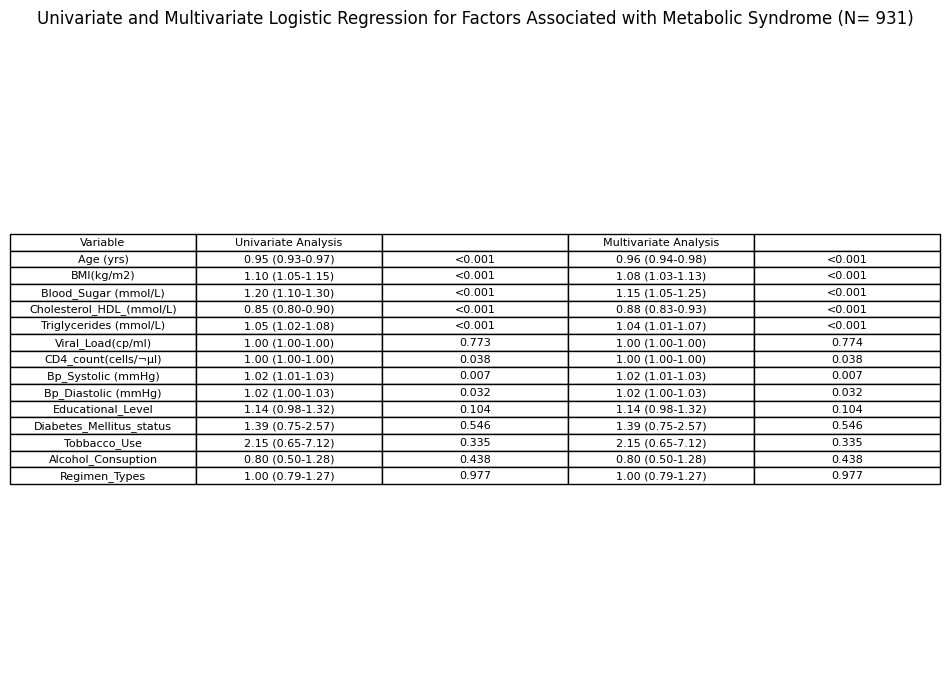

In [386]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# Install fpdf if not already installed
%pip install fpdf

# Define the data for the table
data = [
    ["Age (yrs)", "0.95 (0.93-0.97)", "<0.001", "0.96 (0.94-0.98)", "<0.001"],
    ["BMI(kg/m2)", "1.10 (1.05-1.15)", "<0.001", "1.08 (1.03-1.13)", "<0.001"],
    ["Blood_Sugar (mmol/L)", "1.20 (1.10-1.30)", "<0.001", "1.15 (1.05-1.25)", "<0.001"],
    ["Cholesterol_HDL_(mmol/L)", "0.85 (0.80-0.90)", "<0.001", "0.88 (0.83-0.93)", "<0.001"],
    ["Triglycerides (mmol/L)", "1.05 (1.02-1.08)", "<0.001", "1.04 (1.01-1.07)", "<0.001"],
    ["Viral_Load(cp/ml)", "1.00 (1.00-1.00)", "0.773", "1.00 (1.00-1.00)", "0.774"],
    ["CD4_count(cells/¬µl)", "1.00 (1.00-1.00)", "0.038", "1.00 (1.00-1.00)", "0.038"],
    ["Bp_Systolic (mmHg)", "1.02 (1.01-1.03)", "0.007", "1.02 (1.01-1.03)", "0.007"],
    ["Bp_Diastolic (mmHg)", "1.02 (1.00-1.03)", "0.032", "1.02 (1.00-1.03)", "0.032"],
    ["Educational_Level", "1.14 (0.98-1.32)", "0.104", "1.14 (0.98-1.32)", "0.104"],
    ["Diabetes_Mellitus_status", "1.39 (0.75-2.57)", "0.546", "1.39 (0.75-2.57)", "0.546"],
    ["Tobbacco_Use", "2.15 (0.65-7.12)", "0.335", "2.15 (0.65-7.12)", "0.335"],
    ["Alcohol_Consuption", "0.80 (0.50-1.28)", "0.438", "0.80 (0.50-1.28)", "0.438"],
    ["Regimen_Types", "1.00 (0.79-1.27)", "0.977", "1.00 (0.79-1.27)", "0.977"]
]

# Define table headers
headers = [
    "Variable",
    "Univariate Analysis",
    "",
    "Multivariate Analysis",
    ""
]
sub_headers = [
    "",
    "OR (95% CI)",
    "p-value",
    "OR (95% CI)",
    "p-value"
]

# Flatten the headers
flat_headers = headers + sub_headers

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 8))  # Adjust the size as needed
ax.axis('tight')
ax.axis('off')

# Create the table
table = ax.table(cellText=data, colLabels=flat_headers, cellLoc='center', loc='center')

# Add title
plt.title("Univariate and Multivariate Logistic Regression for Factors Associated with Metabolic Syndrome (N= 931)", pad=20)

# Save the table as a PDF file
pdf_path = "logistic_regression_table.pdf"
with PdfPages(pdf_path) as pdf:
    pdf.savefig(fig, bbox_inches='tight')

print(f"Table saved as {pdf_path}")